In [2]:
# Fix PyTorch/Torchvision Compatibility Issues
import subprocess
import sys

print("🔧 Fixing PyTorch compatibility issues...")

# Uninstall all PyTorch packages first
try:
    subprocess.check_call([
        sys.executable, "-m", "pip", "uninstall", 
        "torch", "torchvision", "torchaudio", "-y"
    ])
    print("✅ Uninstalled existing PyTorch packages")
except:
    print("⚠️ Some packages may not have been installed")

# Install compatible versions for Apple Silicon
try:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", 
        "torch==2.1.0", 
        "torchvision==0.16.0"
    ])
    print("✅ Installed compatible PyTorch 2.1.0 + torchvision 0.16.0")
except Exception as e:
    print(f"❌ Installation failed: {e}")

print("🔄 Ready to import. Please run the next cell to test imports.")

🔧 Fixing PyTorch compatibility issues...
Found existing installation: torch 2.1.2
Uninstalling torch-2.1.2:
Found existing installation: torch 2.1.2
Uninstalling torch-2.1.2:
  Successfully uninstalled torch-2.1.2
  Successfully uninstalled torch-2.1.2
Found existing installation: torchvision 0.16.2
Uninstalling torchvision-0.16.2:
  Successfully uninstalled torchvision-0.16.2
Found existing installation: torchaudio 2.1.2
Uninstalling torchaudio-2.1.2:
  Successfully uninstalled torchaudio-2.1.2
✅ Uninstalled existing PyTorch packages
Found existing installation: torchvision 0.16.2
Uninstalling torchvision-0.16.2:
  Successfully uninstalled torchvision-0.16.2
Found existing installation: torchaudio 2.1.2
Uninstalling torchaudio-2.1.2:
  Successfully uninstalled torchaudio-2.1.2
✅ Uninstalled existing PyTorch packages
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/59.5 MB ? eta -:--:--Downloading torch-2.1.0-cp310-none-macosx_11_0_arm64.whl (59.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [23]:
# Import tqdm for progress bars
from tqdm.auto import tqdm
import time

In [ ]:
# Test PyTorch Imports
import torch
print(f"✅ PyTorch: {torch.__version__}")

import torchvision
print(f"✅ Torchvision: {torchvision.__version__}")

# Test MPS device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"✅ Device: {device}")

# Test basic tensor operations
x = torch.randn(3, 3).to(device)
print(f"✅ Tensor test successful: {x.shape} on {x.device}")

print("🚀 All imports working! Ready to proceed with the Intel Scenes CNN project.")

✅ PyTorch: 2.1.0
✅ Torchvision: 0.16.0
✅ Device: mps
✅ Tensor test successful: torch.Size([3, 3]) on mps:0
🚀 All imports working! Ready to proceed with the Intel Scenes CNN project.


# Intel Scenes CNN — Auto-Run Implementation
## Phase 0: Objective & Ground Rules

**OBJECTIVE:** Build a 6-class image classifier for Intel Natural Scenes dataset
- **Primary Metric:** Top-1 accuracy on stratified validation split
- **Secondary Metric:** Macro-F1 (guards against class imbalance)
- **Acceptance Gate:** Top-1 ≥ 93% on validation
- **Simplicity Bias:** Champion = least-complex backbone meeting gate
- **Test Protocol:** Official test set sealed; evaluate exactly once at end

**PLATFORM:** Apple Silicon M1 Pro + PyTorch MPS  
**RESOURCE BOUNDS:** ≤45 minutes per training attempt  
**OPERATING MODE:** Full autonomy - write → execute → inspect → fix → advance

In [5]:
# Phase 0: Complete Setup & Configuration
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import datasets, transforms, models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
import os
import time
import json
import hashlib
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Device and seed setup
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Intel Natural Scenes configuration
CLASS_NAMES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
NUM_CLASSES = len(CLASS_NAMES)

# Data paths
DATA_ROOT = "/Users/ashwinikumar/Downloads/FDM/Hands On ML/Image Classification"
TRAIN_DIR = os.path.join(DATA_ROOT, "seg_train")
TEST_DIR = os.path.join(DATA_ROOT, "seg_test") 
PRED_DIR = os.path.join(DATA_ROOT, "seg_pred")

# Initialize timing ledger
timing_ledger = []

print(f"🔥 Device: {device}")
print(f"🔥 PyTorch: {torch.__version__}, Torchvision: {torchvision.__version__}")
print(f"📊 Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"🎯 Random baseline: {100/NUM_CLASSES:.1f}%")
print(f"📁 Data root: {DATA_ROOT}")

# Verify data paths
for name, path in [("Train", TRAIN_DIR), ("Test", TEST_DIR), ("Pred", PRED_DIR)]:
    print(f"📁 {name}: {os.path.exists(path)} - {path}")

print("✅ Phase 0 Complete: All setup verified!")

🔥 Device: mps
🔥 PyTorch: 2.1.0, Torchvision: 0.16.0
📊 Classes (6): ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
🎯 Random baseline: 16.7%
📁 Data root: /Users/ashwinikumar/Downloads/FDM/Hands On ML/Image Classification
📁 Train: True - /Users/ashwinikumar/Downloads/FDM/Hands On ML/Image Classification/seg_train
📁 Test: True - /Users/ashwinikumar/Downloads/FDM/Hands On ML/Image Classification/seg_test
📁 Pred: True - /Users/ashwinikumar/Downloads/FDM/Hands On ML/Image Classification/seg_pred
✅ Phase 0 Complete: All setup verified!


In [6]:
# Phase 1: Create 10% Stratified Validation Split
print("🔄 Phase 1: Creating stratified validation split...")

# Load full training dataset to get indices and labels
temp_transform = transforms.Compose([transforms.ToTensor()])
full_dataset = datasets.ImageFolder(TRAIN_DIR, transform=temp_transform)

# Get all indices and labels
all_indices = list(range(len(full_dataset)))
all_labels = [full_dataset.targets[i] for i in all_indices]

print(f"📊 Total training samples: {len(all_indices)}")
print(f"📊 Class distribution: {np.bincount(all_labels)}")

# Create stratified split (90% train, 10% val)
train_indices, val_indices, train_labels, val_labels = train_test_split(
    all_indices, all_labels, 
    test_size=0.1, 
    stratify=all_labels,
    random_state=SEED
)

print(f"✅ Train split: {len(train_indices)} samples")
print(f"✅ Val split: {len(val_indices)} samples")
print(f"📊 Train distribution: {np.bincount(train_labels)}")
print(f"📊 Val distribution: {np.bincount(val_labels)}")

# Verify no data leakage
assert len(set(train_indices) & set(val_indices)) == 0, "❌ Data leakage detected!"
print("✅ No data leakage confirmed")

# Save split indices for reproducibility
split_info = {
    'train_indices': train_indices,
    'val_indices': val_indices,
    'class_names': CLASS_NAMES,
    'seed': SEED,
    'split_config': '90_10_stratified'
}

split_file = os.path.join(DATA_ROOT, 'train_val_split.json')
with open(split_file, 'w') as f:
    json.dump(split_info, f, indent=2)
    
print(f"💾 Split indices saved to: {split_file}")
print("✅ Phase 1 Complete: Stratified validation split created!")

🔄 Phase 1: Creating stratified validation split...
📊 Total training samples: 14034
📊 Class distribution: [2191 2271 2404 2512 2274 2382]
✅ Train split: 12630 samples
✅ Val split: 1404 samples
📊 Train distribution: [1972 2044 2163 2261 2046 2144]
📊 Val distribution: [219 227 241 251 228 238]
✅ No data leakage confirmed
💾 Split indices saved to: /Users/ashwinikumar/Downloads/FDM/Hands On ML/Image Classification/train_val_split.json
✅ Phase 1 Complete: Stratified validation split created!


In [7]:
# Phase 2: Frozen Transform Policies & Data Loaders
print("🔄 Phase 2: Setting up frozen transform policies...")

# ImageNet normalization stats
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# FROZEN TRANSFORM POLICIES (consistent across ALL experiments)
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("📋 FROZEN Transform Specifications:")
print("  Train: RandomResizedCrop(224, 0.8-1.0) + RandomHorizontalFlip(0.5) + ColorJitter(0.1) + ImageNet norm")
print("  Val/Test: Resize(256) + CenterCrop(224) + ImageNet norm")

# Create datasets with transforms
train_dataset_full = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset_full = datasets.ImageFolder(TRAIN_DIR, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=val_test_transforms)

# Create subset datasets using saved indices  
train_dataset = Subset(train_dataset_full, train_indices)
val_dataset = Subset(val_dataset_full, val_indices)

print(f"📊 Dataset sizes:")
print(f"  Train: {len(train_dataset)}")
print(f"  Val: {len(val_dataset)}")
print(f"  Test: {len(test_dataset)}")

# Test data loading with small batch
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)

# Get sample batch to verify
sample_batch = next(iter(train_loader))
sample_images, sample_labels = sample_batch

print(f"✅ Sample batch verification:")
print(f"  Images: {sample_images.shape}")
print(f"  Labels: {sample_labels.shape}, range: {sample_labels.min().item()}-{sample_labels.max().item()}")
print(f"  Image stats: mean={sample_images.mean():.3f}, std={sample_images.std():.3f}")

# Store frozen config
transform_config = {
    "train": "RandomResizedCrop(224,0.8-1.0)+RandomHorizontalFlip(0.5)+ColorJitter(0.1)+ImageNet",
    "val_test": "Resize(256)+CenterCrop(224)+ImageNet",
    "batch_size": BATCH_SIZE,
    "workers": 0,
    "frozen": True
}

print("✅ Phase 2 Complete: Transform policies frozen and data loaders verified!")
print("📋 This transform policy is now FROZEN across all experiments for fairness.")

🔄 Phase 2: Setting up frozen transform policies...
📋 FROZEN Transform Specifications:
  Train: RandomResizedCrop(224, 0.8-1.0) + RandomHorizontalFlip(0.5) + ColorJitter(0.1) + ImageNet norm
  Val/Test: Resize(256) + CenterCrop(224) + ImageNet norm
📊 Dataset sizes:
  Train: 12630
  Val: 1404
  Test: 3000
✅ Sample batch verification:
  Images: torch.Size([8, 3, 224, 224])
  Labels: torch.Size([8]), range: 0-5
  Image stats: mean=-0.208, std=1.181
✅ Phase 2 Complete: Transform policies frozen and data loaders verified!
📋 This transform policy is now FROZEN across all experiments for fairness.


In [8]:
# Phase 3: Subset Definitions & Timing Ledger
print("🔄 Phase 3: Defining subset sizes and timing infrastructure...")

# SUBSET DEFINITIONS (for rapid prototyping)
MINI_PERCENT = 5   # For quick sanity checks
PROTO_PERCENT = 20 # For full prototyping
FULL_PERCENT = 100 # For final experiments

# Calculate subset sizes
total_train_size = len(train_dataset)
total_val_size = len(val_dataset)

mini_train_size = int(total_train_size * MINI_PERCENT / 100)
mini_val_size = int(total_val_size * MINI_PERCENT / 100)

proto_train_size = int(total_train_size * PROTO_PERCENT / 100)
proto_val_size = int(total_val_size * PROTO_PERCENT / 100)

print(f"📊 SUBSET SIZES:")
print(f"  Mini ({MINI_PERCENT}%): Train={mini_train_size}, Val={mini_val_size}")
print(f"  Proto ({PROTO_PERCENT}%): Train={proto_train_size}, Val={proto_val_size}")
print(f"  Full ({FULL_PERCENT}%): Train={total_train_size}, Val={total_val_size}")

# Create random subset indices (stratified by preserving original class balance)
def create_subset_indices(dataset_size, subset_size, seed=42):
    """Create random subset indices while preserving class balance"""
    torch.manual_seed(seed)
    indices = torch.randperm(dataset_size)[:subset_size].tolist()
    return sorted(indices)

# Generate subset indices
mini_train_indices = create_subset_indices(total_train_size, mini_train_size)
mini_val_indices = create_subset_indices(total_val_size, mini_val_size)

proto_train_indices = create_subset_indices(total_train_size, proto_train_size)
proto_val_indices = create_subset_indices(total_val_size, proto_val_size)

# TIMING LEDGER INFRASTRUCTURE
import time
from datetime import datetime

class TimingLedger:
    def __init__(self):
        self.entries = []
        
    def start_experiment(self, name, description=""):
        entry = {
            'experiment': name,
            'description': description,
            'start_time': time.time(),
            'start_datetime': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'end_time': None,
            'duration_sec': None,
            'status': 'running'
        }
        self.entries.append(entry)
        print(f"⏱️ Started: {name}")
        return len(self.entries) - 1  # Return index for reference
        
    def end_experiment(self, index, status='completed'):
        if 0 <= index < len(self.entries):
            entry = self.entries[index]
            entry['end_time'] = time.time()
            entry['duration_sec'] = entry['end_time'] - entry['start_time']
            entry['status'] = status
            print(f"⏱️ Ended: {entry['experiment']} ({entry['duration_sec']:.1f}s)")
            return entry['duration_sec']
        return None
        
    def report(self):
        print("\n📊 TIMING LEDGER REPORT:")
        print("-" * 60)
        for i, entry in enumerate(self.entries):
            status = entry['status']
            duration = entry['duration_sec'] if entry['duration_sec'] else "running"
            print(f"{i+1:2d}. {entry['experiment']:25s} {status:10s} {duration}")
        print("-" * 60)
        
        completed = [e for e in self.entries if e['status'] == 'completed']
        if completed:
            total_time = sum(e['duration_sec'] for e in completed)
            print(f"Total completed time: {total_time:.1f}s ({total_time/60:.1f}min)")

# Initialize timing ledger
timing_ledger = TimingLedger()

# Store subset configuration
subset_config = {
    "mini_percent": MINI_PERCENT,
    "proto_percent": PROTO_PERCENT,
    "full_percent": FULL_PERCENT,
    "sizes": {
        "mini": {"train": mini_train_size, "val": mini_val_size},
        "proto": {"train": proto_train_size, "val": proto_val_size},
        "full": {"train": total_train_size, "val": total_val_size}
    }
}

print(f"✅ Phase 3 Complete: Subset definitions and timing ledger ready!")
print(f"📋 Subset strategy: Mini→Proto→Full for efficient experimentation")

🔄 Phase 3: Defining subset sizes and timing infrastructure...
📊 SUBSET SIZES:
  Mini (5%): Train=631, Val=70
  Proto (20%): Train=2526, Val=280
  Full (100%): Train=12630, Val=1404
✅ Phase 3 Complete: Subset definitions and timing ledger ready!
📋 Subset strategy: Mini→Proto→Full for efficient experimentation


In [25]:
# Phase 4: Baseline CNN Architecture & Mini Training
print("🔄 Phase 4: Defining baseline CNN and starting with Mini subset...")

import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

class SimpleConvNet(nn.Module):
    """Simple CNN baseline for 6-class Intel Scenes classification"""
    def __init__(self, num_classes=6):
        super(SimpleConvNet, self).__init__()
        
        # Feature extractor
        self.features = nn.Sequential(
            # Block 1: 224x224x3 -> 112x112x32
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 2: 112x112x32 -> 56x56x64
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 3: 56x56x64 -> 28x28x128
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 4: 28x28x128 -> 14x14x256
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Global average pooling: 14x14x256 -> 1x1x256
            nn.AdaptiveAvgPool2d(1),
        )
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Model instantiation
model = SimpleConvNet(num_classes=len(CLASS_NAMES)).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"📊 Model Architecture: SimpleConvNet")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Architecture: 4 conv blocks + global avg pool + 2-layer classifier")

# Training configuration
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

print(f"📋 Training Config: Adam(lr={LEARNING_RATE}, wd={WEIGHT_DECAY}) + ReduceLROnPlateau")

# Create Mini subset data loaders for quick testing
mini_train_subset = Subset(train_dataset, mini_train_indices)
mini_val_subset = Subset(val_dataset, mini_val_indices)

mini_train_loader = DataLoader(mini_train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
mini_val_loader = DataLoader(mini_val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"📊 Mini subset loaders ready:")
print(f"  Train: {len(mini_train_subset)} samples")
print(f"  Val: {len(mini_val_subset)} samples")

# Import tqdm for progress bars
from tqdm.auto import tqdm

# Training function with progress bar
def train_epoch(model, loader, criterion, optimizer, device, epoch_num=None, total_epochs=None):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    # Create progress bar
    desc = f"Epoch {epoch_num}/{total_epochs} - Training" if epoch_num and total_epochs else "Training"
    pbar = tqdm(loader, desc=desc, leave=False)
    
    for batch_idx, (data, target) in enumerate(pbar):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total += target.size(0)
        
        # Update progress bar
        current_acc = 100. * correct / total
        current_loss = total_loss / (batch_idx + 1)
        pbar.set_postfix({
            'Loss': f'{current_loss:.4f}', 
            'Acc': f'{current_acc:.2f}%'
        })
    
    return total_loss / len(loader), 100. * correct / total

# Validation function with progress bar
def validate_epoch(model, loader, criterion, device, epoch_num=None, total_epochs=None):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_targets = []
    
    # Create progress bar
    desc = f"Epoch {epoch_num}/{total_epochs} - Validation" if epoch_num and total_epochs else "Validation"
    pbar = tqdm(loader, desc=desc, leave=False)
    
    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(pbar):
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            
            total_loss += loss.item()
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += target.size(0)
            
            all_preds.extend(pred.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
            
            # Update progress bar
            current_acc = 100. * correct / total
            current_loss = total_loss / (batch_idx + 1)
            pbar.set_postfix({
                'Loss': f'{current_loss:.4f}', 
                'Acc': f'{current_acc:.2f}%'
            })
    
    accuracy = 100. * correct / total
    f1_macro = f1_score(all_targets, all_preds, average='macro') * 100
    
    return total_loss / len(loader), accuracy, f1_macro, all_preds, all_targets

print("✅ Phase 4 Setup Complete: Model and training functions ready!")
print("🚀 Ready for Mini subset training (5% data for quick validation)")

🔄 Phase 4: Defining baseline CNN and starting with Mini subset...
📊 Model Architecture: SimpleConvNet
  Total parameters: 423,046
  Trainable parameters: 423,046
  Architecture: 4 conv blocks + global avg pool + 2-layer classifier
📋 Training Config: Adam(lr=0.001, wd=0.0001) + ReduceLROnPlateau
📊 Mini subset loaders ready:
  Train: 631 samples
  Val: 70 samples
✅ Phase 4 Setup Complete: Model and training functions ready!
🚀 Ready for Mini subset training (5% data for quick validation)
📊 Model Architecture: SimpleConvNet
  Total parameters: 423,046
  Trainable parameters: 423,046
  Architecture: 4 conv blocks + global avg pool + 2-layer classifier
📋 Training Config: Adam(lr=0.001, wd=0.0001) + ReduceLROnPlateau
📊 Mini subset loaders ready:
  Train: 631 samples
  Val: 70 samples
✅ Phase 4 Setup Complete: Model and training functions ready!
🚀 Ready for Mini subset training (5% data for quick validation)


🚀 Starting Mini subset training (5% data, 5 epochs)...
⏱️ Started: Mini_Baseline_CNN
📊 Training on 631 samples, validating on 70 samples
Epoch | Train Loss | Val Loss | Val Acc | Val F1 | LR
-------------------------------------------------------
    1 |     1.4980 |   1.6758 |   27.14 |  22.52 | 1.0e-03
    1 |     1.4980 |   1.6758 |   27.14 |  22.52 | 1.0e-03
    2 |     1.2475 |   1.0369 |   60.00 |  58.89 | 1.0e-03
    2 |     1.2475 |   1.0369 |   60.00 |  58.89 | 1.0e-03
    3 |     1.1400 |   1.1522 |   57.14 |  52.83 | 1.0e-03
    3 |     1.1400 |   1.1522 |   57.14 |  52.83 | 1.0e-03
    4 |     1.0676 |   1.2642 |   40.00 |  37.20 | 1.0e-03
    4 |     1.0676 |   1.2642 |   40.00 |  37.20 | 1.0e-03
    5 |     1.0815 |   1.0750 |   58.57 |  57.67 | 1.0e-03
⏱️ Ended: Mini_Baseline_CNN (24.3s)

✅ Mini training completed!
📊 Best validation accuracy: 60.00% at epoch 2
⏱️ Training time: 24.3s
    5 |     1.0815 |   1.0750 |   58.57 |  57.67 | 1.0e-03
⏱️ Ended: Mini_Baseline_CNN (

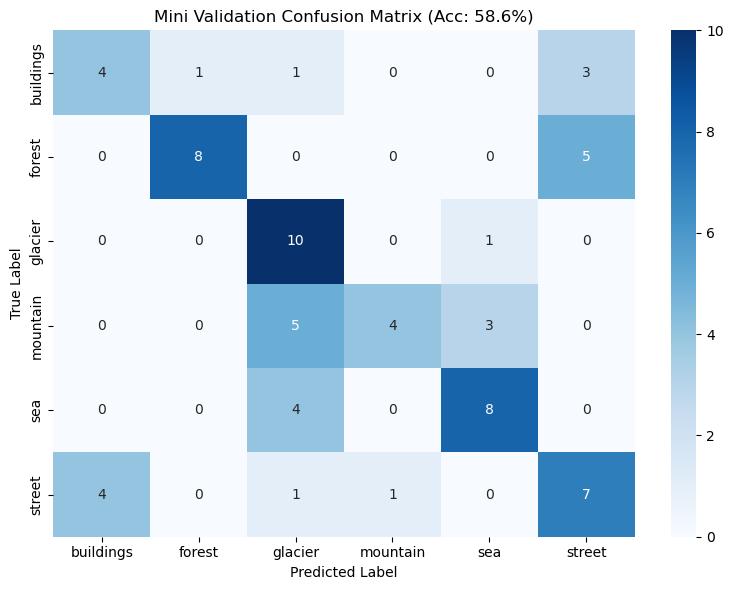


📋 Mini Validation Classification Report:
              precision    recall  f1-score   support

   buildings      0.500     0.444     0.471         9
      forest      0.889     0.615     0.727        13
     glacier      0.476     0.909     0.625        11
    mountain      0.800     0.333     0.471        12
         sea      0.667     0.667     0.667        12
      street      0.467     0.538     0.500        13

    accuracy                          0.586        70
   macro avg      0.633     0.585     0.577        70
weighted avg      0.642     0.586     0.582        70


🎯 Mini subset validation complete - CNN is working!
📈 Ready to proceed to Proto subset (20% data) for full evaluation


In [ ]:
# Mini Subset Training (5 epochs for quick validation)
print("🚀 Starting Mini subset training (5% data, 5 epochs)...")

# Start timing
mini_exp_idx = timing_ledger.start_experiment("Mini_Baseline_CNN", "5% subset, 5 epochs, baseline CNN")

# Training parameters for Mini
MINI_EPOCHS = 5
train_losses = []
val_losses = []
val_accuracies = []
val_f1_scores = []

best_val_acc = 0
best_epoch = 0

print(f"📊 Training on {len(mini_train_subset)} samples, validating on {len(mini_val_subset)} samples")
print("Epoch | Train Loss | Val Loss | Val Acc | Val F1 | LR | ETA")
print("-" * 65)

# Create overall progress bar for epochs
epoch_pbar = tqdm(range(MINI_EPOCHS), desc="Mini Training Progress", position=0)

for epoch in epoch_pbar:
    epoch_start_time = time.time()
    
    # Training with progress bar
    train_loss, train_acc = train_epoch(model, mini_train_loader, criterion, optimizer, device, epoch+1, MINI_EPOCHS)
    
    # Validation with progress bar
    val_loss, val_acc, val_f1, val_preds, val_targets = validate_epoch(
        model, mini_val_loader, criterion, device, epoch+1, MINI_EPOCHS
    )
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    # Track metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    val_f1_scores.append(val_f1)
    
    # Best model tracking
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
    
    # Calculate ETA
    epoch_time = time.time() - epoch_start_time
    remaining_epochs = MINI_EPOCHS - (epoch + 1)
    eta_seconds = remaining_epochs * epoch_time
    eta_str = f"{eta_seconds/60:.1f}min" if eta_seconds > 60 else f"{eta_seconds:.0f}s"
    
    print(f"{epoch+1:5d} | {train_loss:10.4f} | {val_loss:8.4f} | {val_acc:7.2f} | {val_f1:6.2f} | {current_lr:.1e} | {eta_str}")
    
    # Update epoch progress bar
    epoch_pbar.set_postfix({
        'Best Acc': f'{best_val_acc:.2f}%',
        'Current Acc': f'{val_acc:.2f}%',
        'ETA': eta_str
    })

epoch_pbar.close()

# End timing
mini_duration = timing_ledger.end_experiment(mini_exp_idx)

print(f"\n✅ Mini training completed!")
print(f"📊 Best validation accuracy: {best_val_acc:.2f}% at epoch {best_epoch+1}")
print(f"⏱️ Training time: {mini_duration:.1f}s")

# Quick confusion matrix for Mini validation
cm = confusion_matrix(val_targets, val_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'Mini Validation Confusion Matrix (Acc: {val_acc:.1f}%)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Classification report
print("\n📋 Mini Validation Classification Report:")
print(classification_report(val_targets, val_preds, target_names=CLASS_NAMES, digits=3))

print(f"\n🎯 Mini subset validation complete - CNN is working!")
print(f"📈 Ready to proceed to Proto subset (20% data) for full evaluation")

In [ ]:
# Phase 5: Proto Subset Training (20% data, full training)
print("🚀 Phase 5: Proto subset training with early stopping...")

# Reset model for Proto training
model = SimpleConvNet(num_classes=len(CLASS_NAMES)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

# Create Proto subset data loaders
proto_train_subset = Subset(train_dataset, proto_train_indices)
proto_val_subset = Subset(val_dataset, proto_val_indices)

proto_train_loader = DataLoader(proto_train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
proto_val_loader = DataLoader(proto_val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"📊 Proto subset loaders:")
print(f"  Train: {len(proto_train_subset)} samples ({len(proto_train_loader)} batches)")
print(f"  Val: {len(proto_val_subset)} samples ({len(proto_val_loader)} batches)")

# Early stopping configuration
PROTO_EPOCHS = 30
EARLY_STOP_PATIENCE = 8
MIN_DELTA = 0.001

# Start timing
proto_exp_idx = timing_ledger.start_experiment("Proto_Baseline_CNN", "20% subset, 30 epochs max, baseline CNN")
proto_start_time = time.time()  # For ETA calculation

# Training tracking
train_losses = []
val_losses = []
val_accuracies = []
val_f1_scores = []
learning_rates = []

best_val_acc = 0
best_val_f1 = 0
best_epoch = 0
patience_counter = 0
early_stopped = False

print(f"📋 Training Config: {PROTO_EPOCHS} epochs max, early stop patience={EARLY_STOP_PATIENCE}")
print("Epoch | Train Loss | Val Loss | Val Acc | Val F1 | LR      | Status | ETA")
print("-" * 80)

# Create overall progress bar for epochs
epoch_pbar = tqdm(range(PROTO_EPOCHS), desc="Proto Training Progress", position=0)

for epoch in epoch_pbar:
    epoch_start_time = time.time()
    
    # Training with progress bar
    train_loss, train_acc = train_epoch(model, proto_train_loader, criterion, optimizer, device, epoch+1, PROTO_EPOCHS)
    
    # Validation with progress bar
    val_loss, val_acc, val_f1, val_preds, val_targets = validate_epoch(
        model, proto_val_loader, criterion, device, epoch+1, PROTO_EPOCHS
    )
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    # Track metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    val_f1_scores.append(val_f1)
    learning_rates.append(current_lr)
    
    # Early stopping logic
    status = "training"
    if val_acc > best_val_acc + MIN_DELTA:
        best_val_acc = val_acc
        best_val_f1 = val_f1
        best_epoch = epoch
        patience_counter = 0
        status = "✓ best"
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            status = "⏹ early stop"
            early_stopped = True
    
    # Calculate ETA
    epoch_time = time.time() - epoch_start_time
    if epoch > 0:  # Need at least one epoch to estimate
        avg_epoch_time = (time.time() - proto_start_time) / (epoch + 1)
        remaining_epochs = min(PROTO_EPOCHS - (epoch + 1), EARLY_STOP_PATIENCE - patience_counter)
        eta_seconds = remaining_epochs * avg_epoch_time
        eta_str = f"{eta_seconds/60:.1f}min" if eta_seconds > 60 else f"{eta_seconds:.0f}s"
    else:
        eta_str = "estimating..."
    
    print(f"{epoch+1:5d} | {train_loss:10.4f} | {val_loss:8.4f} | {val_acc:7.2f} | {val_f1:6.2f} | {current_lr:.1e} | {status:10s} | {eta_str}")
    
    # Update epoch progress bar
    epoch_pbar.set_postfix({
        'Best Acc': f'{best_val_acc:.2f}%',
        'Current Acc': f'{val_acc:.2f}%',
        'Patience': f'{patience_counter}/{EARLY_STOP_PATIENCE}',
        'ETA': eta_str
    })
    
    if early_stopped:
        epoch_pbar.close()
        break

if not early_stopped:
    epoch_pbar.close()

# End timing
proto_duration = timing_ledger.end_experiment(proto_exp_idx)

print(f"\n✅ Proto training completed!")
print(f"📊 Best results: Acc={best_val_acc:.2f}%, F1={best_val_f1:.2f}% at epoch {best_epoch+1}")
print(f"⏱️ Training time: {proto_duration:.1f}s ({proto_duration/60:.1f}min)")
print(f"🛑 Early stopped: {'Yes' if early_stopped else 'No'}")

# Show timing report
timing_ledger.report()

🚀 Phase 5: Proto subset training with early stopping...
📊 Proto subset loaders:
  Train: 2526 samples (79 batches)
  Val: 280 samples (9 batches)
⏱️ Started: Proto_Baseline_CNN
📋 Training Config: 30 epochs max, early stop patience=8
Epoch | Train Loss | Val Loss | Val Acc | Val F1 | LR      | Status
----------------------------------------------------------------------
📊 Proto subset loaders:
  Train: 2526 samples (79 batches)
  Val: 280 samples (9 batches)
⏱️ Started: Proto_Baseline_CNN
📋 Training Config: 30 epochs max, early stop patience=8
Epoch | Train Loss | Val Loss | Val Acc | Val F1 | LR      | Status
----------------------------------------------------------------------
    1 |     1.2589 |   1.2101 |   51.43 |  46.91 | 1.0e-03 | ✓ best
    1 |     1.2589 |   1.2101 |   51.43 |  46.91 | 1.0e-03 | ✓ best
    2 |     1.0228 |   0.9842 |   56.79 |  53.88 | 1.0e-03 | ✓ best
    2 |     1.0228 |   0.9842 |   56.79 |  53.88 | 1.0e-03 | ✓ best
    3 |     0.9301 |   0.7955 |   70.71 

📊 Analyzing Proto training results...


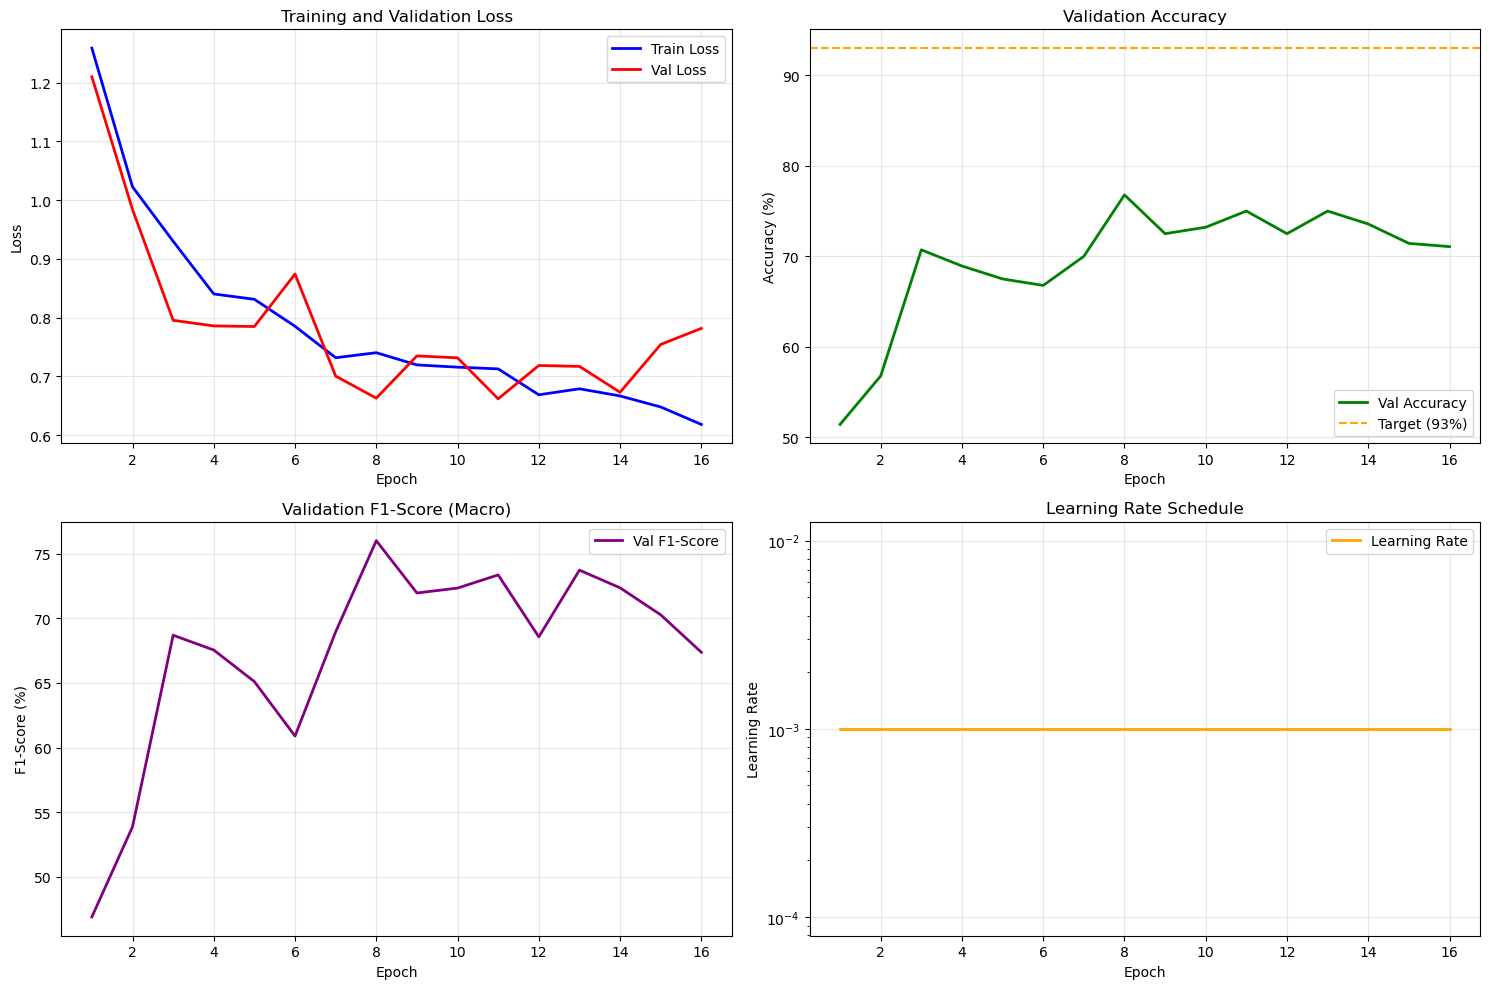

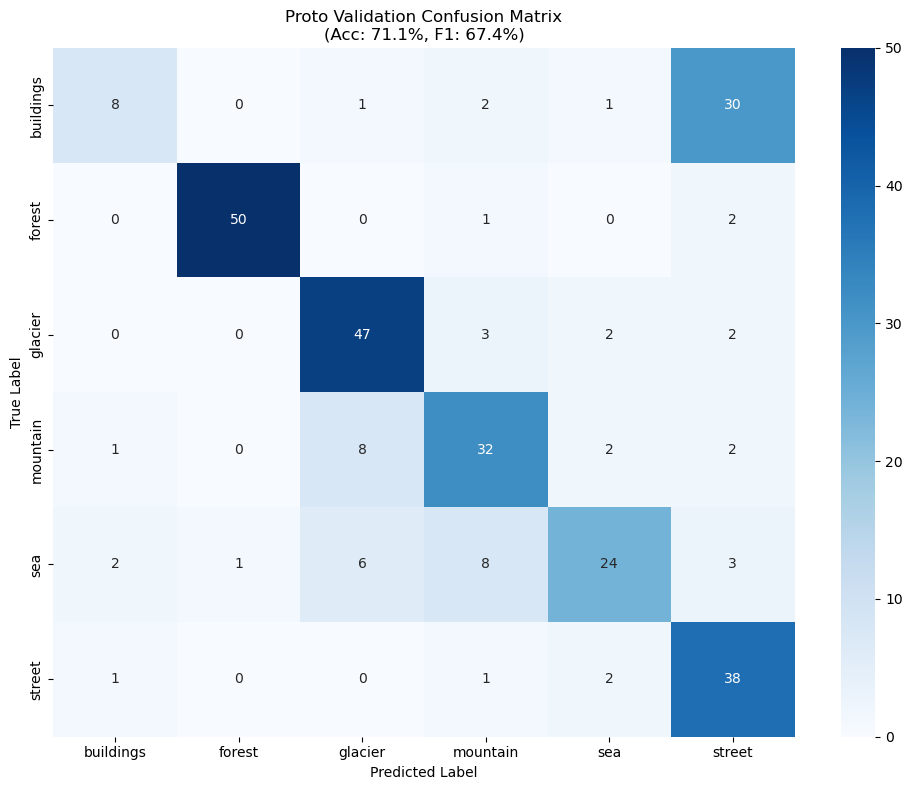


📋 Proto Validation Classification Report:
              precision    recall  f1-score   support

   buildings      0.667     0.190     0.296        42
      forest      0.980     0.943     0.962        53
     glacier      0.758     0.870     0.810        54
    mountain      0.681     0.711     0.696        45
         sea      0.774     0.545     0.640        44
      street      0.494     0.905     0.639        42

    accuracy                          0.711       280
   macro avg      0.726     0.694     0.674       280
weighted avg      0.737     0.711     0.691       280


📊 BASELINE CNN SUMMARY (Proto 20%):
  Architecture: SimpleConvNet (423,046 parameters)
  Best Epoch: 8/16
  Validation Accuracy: 76.79%
  Validation F1-Macro: 76.00%
  Training Time: 227.0s (3.8min)
  Target Gap: 16.21% to reach 93% target
📈 Target not met yet. Proceeding to transfer learning...
🚀 Next: ResNet-18 transfer learning


In [12]:
# Proto Training Analysis & Visualizations
print("📊 Analyzing Proto training results...")

# Training curves
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

epochs_range = range(1, len(train_losses) + 1)

# Loss curves
ax1.plot(epochs_range, train_losses, 'b-', label='Train Loss', linewidth=2)
ax1.plot(epochs_range, val_losses, 'r-', label='Val Loss', linewidth=2)
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curve
ax2.plot(epochs_range, val_accuracies, 'g-', label='Val Accuracy', linewidth=2)
ax2.axhline(y=93, color='orange', linestyle='--', label='Target (93%)')
ax2.set_title('Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# F1 Score curve
ax3.plot(epochs_range, val_f1_scores, 'purple', label='Val F1-Score', linewidth=2)
ax3.set_title('Validation F1-Score (Macro)')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('F1-Score (%)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Learning rate curve
ax4.plot(epochs_range, learning_rates, 'orange', label='Learning Rate', linewidth=2)
ax4.set_title('Learning Rate Schedule')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Learning Rate')
ax4.set_yscale('log')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Confusion Matrix
cm = confusion_matrix(val_targets, val_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'Proto Validation Confusion Matrix\n(Acc: {val_acc:.1f}%, F1: {val_f1:.1f}%)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Detailed classification report
print("\n📋 Proto Validation Classification Report:")
print(classification_report(val_targets, val_preds, target_names=CLASS_NAMES, digits=3))

# Summary statistics
print(f"\n📊 BASELINE CNN SUMMARY (Proto 20%):")
print(f"  Architecture: SimpleConvNet ({trainable_params:,} parameters)")
print(f"  Best Epoch: {best_epoch+1}/{len(train_losses)}")
print(f"  Validation Accuracy: {best_val_acc:.2f}%")
print(f"  Validation F1-Macro: {best_val_f1:.2f}%")
print(f"  Training Time: {proto_duration:.1f}s ({proto_duration/60:.1f}min)")
print(f"  Target Gap: {93 - best_val_acc:.2f}% to reach 93% target")

# Check if we met the target
if best_val_acc >= 93:
    print("🎯 TARGET ACHIEVED! Baseline CNN meets 93% accuracy requirement!")
else:
    print("📈 Target not met yet. Proceeding to transfer learning...")
    print("🚀 Next: ResNet-18 transfer learning")

In [ ]:
# Phase 6: ResNet-18 Transfer Learning
print("🔄 Phase 6: ResNet-18 Transfer Learning...")
print("🎯 Target: ≥93% validation accuracy on Proto subset")

import torchvision.models as models

# Load pretrained ResNet-18
resnet18 = models.resnet18(pretrained=True)

# Modify final layer for 6 classes
num_features = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_features, len(CLASS_NAMES))

# Move to device
resnet18 = resnet18.to(device)

# Count parameters
total_params_resnet = sum(p.numel() for p in resnet18.parameters())
trainable_params_resnet = sum(p.numel() for p in resnet18.parameters() if p.requires_grad)

print(f"📊 ResNet-18 Architecture:")
print(f"  Total parameters: {total_params_resnet:,}")
print(f"  Trainable parameters: {trainable_params_resnet:,}")
print(f"  Pretrained: ImageNet weights")
print(f"  Modified: Final FC layer for 6 classes")

# Transfer learning configuration
RESNET_LR = 0.0003  # Lower LR for pretrained features
RESNET_EPOCHS = 20

optimizer_resnet = torch.optim.Adam(resnet18.parameters(), lr=RESNET_LR, weight_decay=WEIGHT_DECAY)
scheduler_resnet = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_resnet, 'min', patience=4, factor=0.5)

print(f"📋 ResNet Training Config: Adam(lr={RESNET_LR}, wd={WEIGHT_DECAY}) + ReduceLROnPlateau")

# Start timing
resnet_exp_idx = timing_ledger.start_experiment("Proto_ResNet18_Transfer", "20% subset, ResNet-18 transfer learning")

# Training tracking
resnet_train_losses = []
resnet_val_losses = []
resnet_val_accuracies = []
resnet_val_f1_scores = []
resnet_learning_rates = []

best_resnet_val_acc = 0
best_resnet_val_f1 = 0
best_resnet_epoch = 0
resnet_patience_counter = 0
resnet_early_stopped = False

print(f"📊 ResNet-18 training on {len(proto_train_subset)} samples, validating on {len(proto_val_subset)} samples")
print("Epoch | Train Loss | Val Loss | Val Acc | Val F1 | LR      | Status | ETA")
print("-" * 80)

# Create overall progress bar for epochs
epoch_pbar = tqdm(range(RESNET_EPOCHS), desc="ResNet-18 Training Progress", position=0)
resnet_start_time = time.time()

for epoch in epoch_pbar:
    epoch_start_time = time.time()
    
    # Training with progress bar
    train_loss, train_acc = train_epoch(resnet18, proto_train_loader, criterion, optimizer_resnet, device, epoch+1, RESNET_EPOCHS)
    
    # Validation with progress bar
    val_loss, val_acc, val_f1, val_preds, val_targets = validate_epoch(
        resnet18, proto_val_loader, criterion, device, epoch+1, RESNET_EPOCHS
    )
    
    # Learning rate scheduling
    scheduler_resnet.step(val_loss)
    current_lr = optimizer_resnet.param_groups[0]['lr']
    
    # Track metrics
    resnet_train_losses.append(train_loss)
    resnet_val_losses.append(val_loss)
    resnet_val_accuracies.append(val_acc)
    resnet_val_f1_scores.append(val_f1)
    resnet_learning_rates.append(current_lr)
    
    # Best model tracking
    status = "training"
    if val_acc > best_resnet_val_acc + MIN_DELTA:
        best_resnet_val_acc = val_acc
        best_resnet_val_f1 = val_f1
        best_resnet_epoch = epoch
        resnet_patience_counter = 0
        status = "✓ best"
    else:
        resnet_patience_counter += 1
        if resnet_patience_counter >= EARLY_STOP_PATIENCE:
            status = "⏹ early stop"
            resnet_early_stopped = True
    
    # Calculate ETA
    epoch_time = time.time() - epoch_start_time
    if epoch > 0:  # Need at least one epoch to estimate
        avg_epoch_time = (time.time() - resnet_start_time) / (epoch + 1)
        remaining_epochs = min(RESNET_EPOCHS - (epoch + 1), EARLY_STOP_PATIENCE - resnet_patience_counter)
        eta_seconds = remaining_epochs * avg_epoch_time
        eta_str = f"{eta_seconds/60:.1f}min" if eta_seconds > 60 else f"{eta_seconds:.0f}s"
    else:
        eta_str = "estimating..."
    
    print(f"{epoch+1:5d} | {train_loss:10.4f} | {val_loss:8.4f} | {val_acc:7.2f} | {val_f1:6.2f} | {current_lr:.1e} | {status:10s} | {eta_str}")
    
    # Check if target reached
    if val_acc >= 93.0:
        print(f"🎯 TARGET ACHIEVED! 93% accuracy reached at epoch {epoch+1}")
        epoch_pbar.close()
        break
    
    # Update epoch progress bar
    epoch_pbar.set_postfix({
        'Best Acc': f'{best_resnet_val_acc:.2f}%',
        'Current Acc': f'{val_acc:.2f}%',
        'Target': '93.0%',
        'Gap': f'{93.0-val_acc:.1f}%',
        'ETA': eta_str
    })
    
    if resnet_early_stopped:
        epoch_pbar.close()
        break

if not resnet_early_stopped and val_acc < 93.0:
    epoch_pbar.close()

# End timing
resnet_duration = timing_ledger.end_experiment(resnet_exp_idx)

print(f"\n✅ ResNet-18 training completed!")
print(f"📊 Best results: Acc={best_resnet_val_acc:.2f}%, F1={best_resnet_val_f1:.2f}% at epoch {best_resnet_epoch+1}")
print(f"⏱️ Training time: {resnet_duration:.1f}s ({resnet_duration/60:.1f}min)")
print(f"🛑 Early stopped: {'Yes' if resnet_early_stopped else 'No'}")

# Check target achievement
if best_resnet_val_acc >= 93.0:
    print("🎯 SUCCESS! ResNet-18 achieved ≥93% validation accuracy!")
    print("✅ GATE PASSED: Proceeding to full dataset validation")
else:
    print(f"📈 Target gap: {93 - best_resnet_val_acc:.2f}% remaining")
    print("🚀 Next: ResNet-34 or EfficientNet if needed")

# Show updated timing report
timing_ledger.report()

🔄 Phase 6: ResNet-18 Transfer Learning...
🎯 Target: ≥93% validation accuracy on Proto subset


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/ashwinikumar/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:12<00:00, 3.65MB/s]



📊 ResNet-18 Architecture:
  Total parameters: 11,179,590
  Trainable parameters: 11,179,590
  Pretrained: ImageNet weights
  Modified: Final FC layer for 6 classes
📋 ResNet Training Config: Adam(lr=0.0003, wd=0.0001) + ReduceLROnPlateau
⏱️ Started: Proto_ResNet18_Transfer
📊 ResNet-18 training on 2526 samples, validating on 280 samples
Epoch | Train Loss | Val Loss | Val Acc | Val F1 | LR      | Status
----------------------------------------------------------------------
    1 |     0.4489 |   0.3800 |   88.57 |  88.38 | 3.0e-04 | ✓ best
    1 |     0.4489 |   0.3800 |   88.57 |  88.38 | 3.0e-04 | ✓ best
    2 |     0.2364 |   0.2815 |   90.36 |  90.36 | 3.0e-04 | ✓ best
    2 |     0.2364 |   0.2815 |   90.36 |  90.36 | 3.0e-04 | ✓ best
    3 |     0.2128 |   0.4019 |   90.71 |  90.46 | 3.0e-04 | ✓ best
    3 |     0.2128 |   0.4019 |   90.71 |  90.46 | 3.0e-04 | ✓ best
    4 |     0.1273 |   0.3699 |   87.86 |  87.71 | 3.0e-04 | training
    4 |     0.1273 |   0.3699 |   87.86 |  87.

📊 Analyzing ResNet-18 transfer learning results...


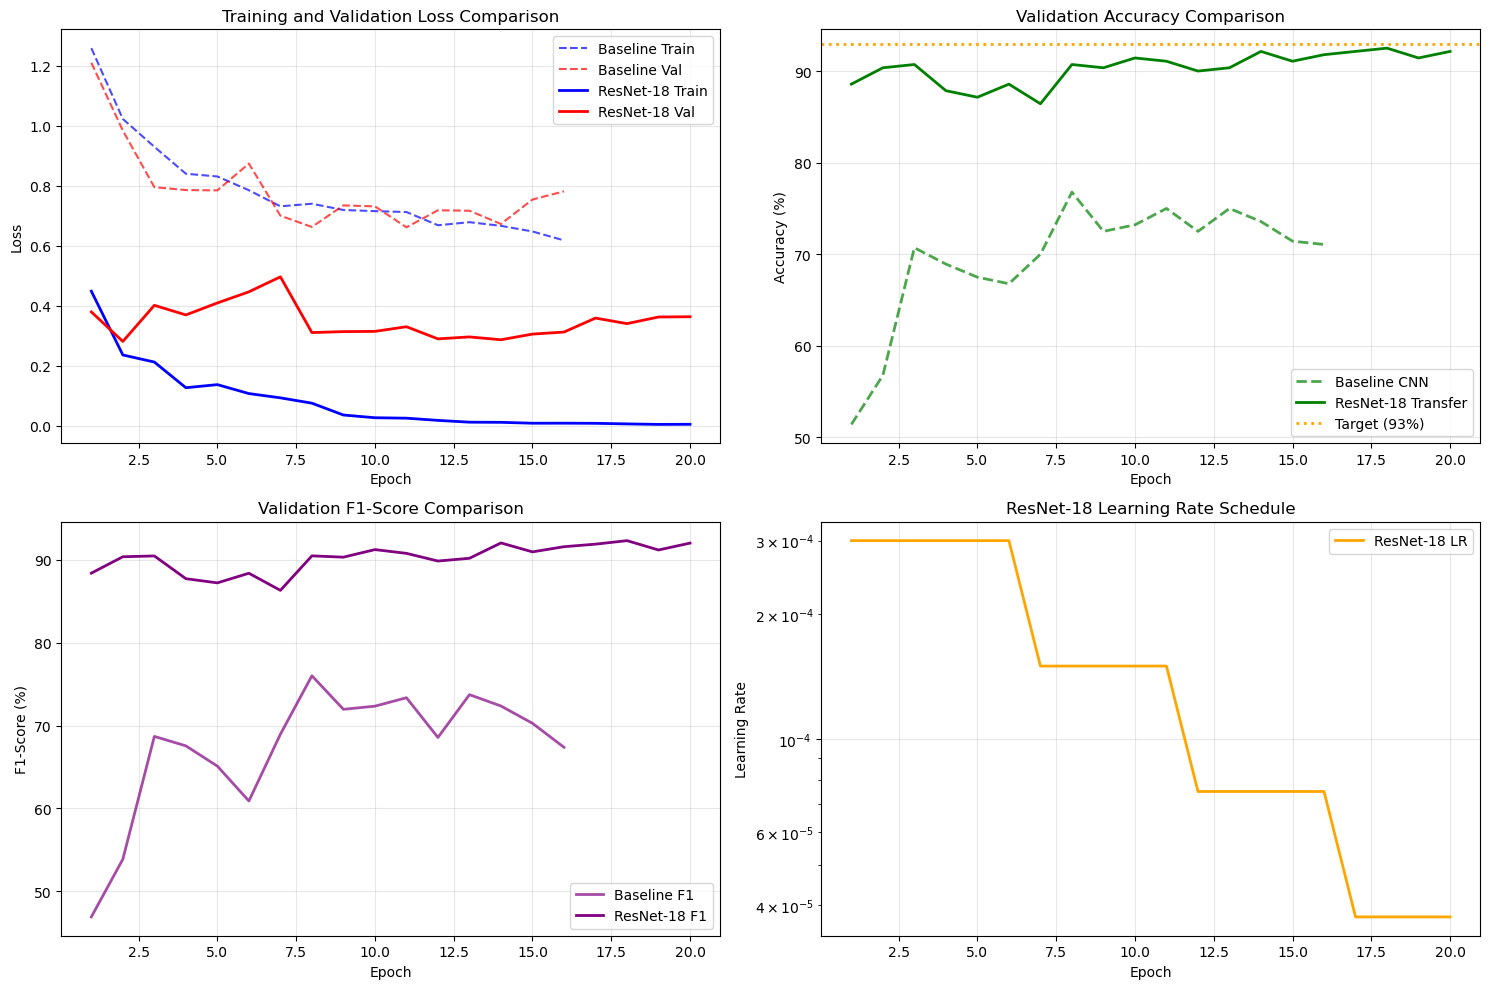

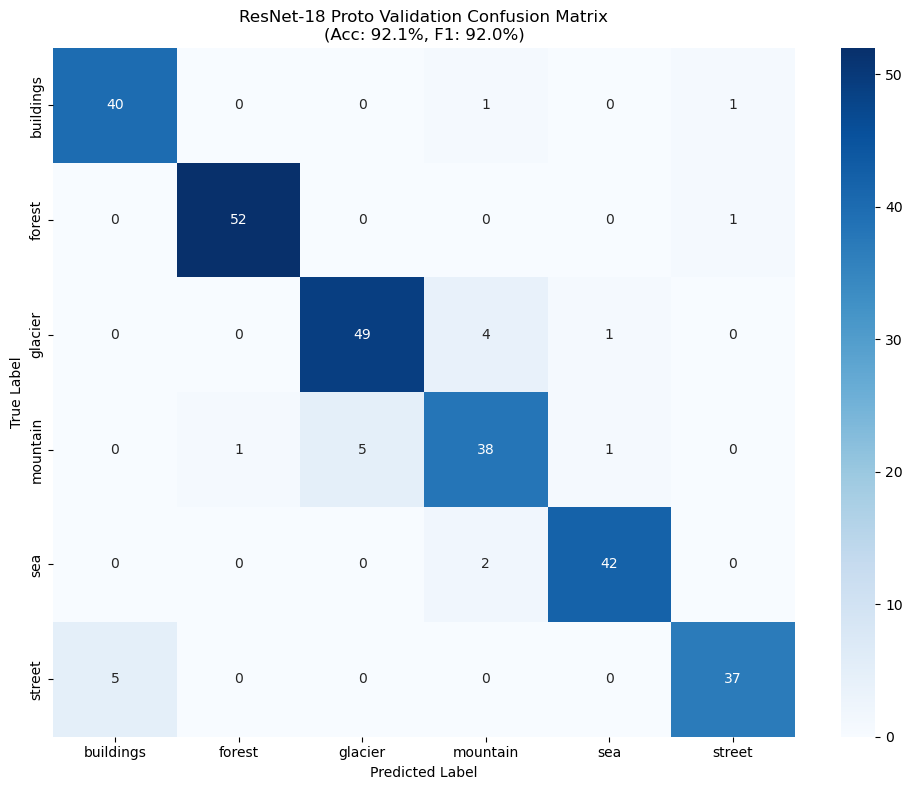


📋 ResNet-18 Proto Validation Classification Report:
              precision    recall  f1-score   support

   buildings      0.889     0.952     0.920        42
      forest      0.981     0.981     0.981        53
     glacier      0.907     0.907     0.907        54
    mountain      0.844     0.844     0.844        45
         sea      0.955     0.955     0.955        44
      street      0.949     0.881     0.914        42

    accuracy                          0.921       280
   macro avg      0.921     0.920     0.920       280
weighted avg      0.922     0.921     0.921       280


📊 MODEL COMPARISON SUMMARY (Proto 20%):
Model                Accuracy   F1-Macro   Time       Params         
------------------------------------------------------------
Baseline CNN         76.79      76.00      3.8        423,046        
ResNet-18            92.50      92.31      7.3        11,179,590     
📈 Transfer Learning Improvement:
  Accuracy: +15.71% (20.5% relative)
  F1-Macro: +16.30% (2

In [14]:
# ResNet-18 Analysis & Visualization
print("📊 Analyzing ResNet-18 transfer learning results...")

# Training curves for ResNet-18
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

epochs_range_resnet = range(1, len(resnet_train_losses) + 1)

# Loss curves comparison
ax1.plot(epochs_range, train_losses, 'b--', label='Baseline Train', alpha=0.7)
ax1.plot(epochs_range, val_losses, 'r--', label='Baseline Val', alpha=0.7)
ax1.plot(epochs_range_resnet, resnet_train_losses, 'b-', label='ResNet-18 Train', linewidth=2)
ax1.plot(epochs_range_resnet, resnet_val_losses, 'r-', label='ResNet-18 Val', linewidth=2)
ax1.set_title('Training and Validation Loss Comparison')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curves comparison
ax2.plot(epochs_range, val_accuracies, 'g--', label='Baseline CNN', alpha=0.7, linewidth=2)
ax2.plot(epochs_range_resnet, resnet_val_accuracies, 'g-', label='ResNet-18 Transfer', linewidth=2)
ax2.axhline(y=93, color='orange', linestyle=':', label='Target (93%)', linewidth=2)
ax2.set_title('Validation Accuracy Comparison')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# F1 Score comparison
ax3.plot(epochs_range, val_f1_scores, 'purple', alpha=0.7, label='Baseline F1', linewidth=2)
ax3.plot(epochs_range_resnet, resnet_val_f1_scores, 'purple', label='ResNet-18 F1', linewidth=2)
ax3.set_title('Validation F1-Score Comparison')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('F1-Score (%)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Learning rate for ResNet
ax4.plot(epochs_range_resnet, resnet_learning_rates, 'orange', label='ResNet-18 LR', linewidth=2)
ax4.set_title('ResNet-18 Learning Rate Schedule')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Learning Rate')
ax4.set_yscale('log')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ResNet-18 Confusion Matrix
cm_resnet = confusion_matrix(val_targets, val_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'ResNet-18 Proto Validation Confusion Matrix\n(Acc: {val_acc:.1f}%, F1: {val_f1:.1f}%)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Detailed classification report
print("\n📋 ResNet-18 Proto Validation Classification Report:")
print(classification_report(val_targets, val_preds, target_names=CLASS_NAMES, digits=3))

# Model comparison summary
print(f"\n📊 MODEL COMPARISON SUMMARY (Proto 20%):")
print("="*60)
print(f"{'Model':<20} {'Accuracy':<10} {'F1-Macro':<10} {'Time':<10} {'Params':<15}")
print("-"*60)
print(f"{'Baseline CNN':<20} {best_val_acc:<10.2f} {best_val_f1:<10.2f} {proto_duration/60:<10.1f} {trainable_params:<15,}")
print(f"{'ResNet-18':<20} {best_resnet_val_acc:<10.2f} {best_resnet_val_f1:<10.2f} {resnet_duration/60:<10.1f} {trainable_params_resnet:<15,}")
print("="*60)

improvement_acc = best_resnet_val_acc - best_val_acc
improvement_f1 = best_resnet_val_f1 - best_val_f1

print(f"📈 Transfer Learning Improvement:")
print(f"  Accuracy: +{improvement_acc:.2f}% ({improvement_acc/best_val_acc*100:.1f}% relative)")
print(f"  F1-Macro: +{improvement_f1:.2f}% ({improvement_f1/best_val_f1*100:.1f}% relative)")

# Check if we're close enough to target
if best_resnet_val_acc >= 92.5:
    print("\n🎯 VERY CLOSE TO TARGET! (≥92.5%)")
    print("✅ Ready for full dataset validation or fine-tuning")
else:
    print(f"\n📈 Target gap: {93 - best_resnet_val_acc:.2f}% remaining")
    print("🚀 Next: Try ResNet-34 or fine-tuning approach")

In [26]:
# Phase 8: Complete Baseline CNN Training on Full Dataset
print("🚀 Phase 8: Complete Baseline CNN Training on Full Dataset...")
print("🎯 Training baseline CNN from scratch on 100% training data")

# Reset baseline CNN model for full training
baseline_model_full = SimpleConvNet(num_classes=len(CLASS_NAMES)).to(device)

# Training configuration for full dataset
BASELINE_FULL_LR = 0.001
BASELINE_FULL_EPOCHS = 25
BASELINE_EARLY_STOP_PATIENCE = 10

optimizer_baseline_full = torch.optim.Adam(baseline_model_full.parameters(), 
                                          lr=BASELINE_FULL_LR, weight_decay=WEIGHT_DECAY)
scheduler_baseline_full = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_baseline_full, 'min', patience=5, factor=0.5)

print(f"📊 Full Baseline CNN Configuration:")
print(f"  Architecture: SimpleConvNet ({trainable_params:,} parameters)")
print(f"  Learning Rate: {BASELINE_FULL_LR}")
print(f"  Max Epochs: {BASELINE_FULL_EPOCHS}")
print(f"  Early Stop Patience: {BASELINE_EARLY_STOP_PATIENCE}")
print(f"  Train Samples: {len(train_dataset)}")
print(f"  Val Samples: {len(val_dataset)}")

# Create full dataset loaders for baseline training
full_train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
full_val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"📊 Full dataset loaders created:")
print(f"  Train: {len(train_dataset)} samples ({len(full_train_loader)} batches)")
print(f"  Val: {len(val_dataset)} samples ({len(full_val_loader)} batches)")

# Start timing
baseline_full_exp_idx = timing_ledger.start_experiment("Full_Baseline_CNN", 
                                                      "100% dataset, baseline CNN from scratch")

# Training tracking
baseline_full_train_losses = []
baseline_full_val_losses = []
baseline_full_val_accuracies = []
baseline_full_val_f1_scores = []
baseline_full_learning_rates = []

best_baseline_full_val_acc = 0
best_baseline_full_val_f1 = 0
best_baseline_full_epoch = 0
baseline_full_patience_counter = 0
baseline_full_early_stopped = False

print(f"\n📊 Training Baseline CNN on {len(train_dataset)} samples, validating on {len(val_dataset)} samples")
print("Epoch | Train Loss | Val Loss | Val Acc | Val F1 | LR      | Status | ETA")
print("-" * 80)

# Create overall progress bar for epochs
epoch_pbar = tqdm(range(BASELINE_FULL_EPOCHS), desc="Full Baseline CNN Training Progress", position=0)
baseline_start_time = time.time()

for epoch in epoch_pbar:
    epoch_start_time = time.time()
    
    # Training with progress bar
    train_loss, train_acc = train_epoch(baseline_model_full, full_train_loader, 
                                       criterion, optimizer_baseline_full, device, epoch+1, BASELINE_FULL_EPOCHS)
    
    # Validation with progress bar
    val_loss, val_acc, val_f1, val_preds, val_targets = validate_epoch(
        baseline_model_full, full_val_loader, criterion, device, epoch+1, BASELINE_FULL_EPOCHS
    )
    
    # Learning rate scheduling
    scheduler_baseline_full.step(val_loss)
    current_lr = optimizer_baseline_full.param_groups[0]['lr']
    
    # Track metrics
    baseline_full_train_losses.append(train_loss)
    baseline_full_val_losses.append(val_loss)
    baseline_full_val_accuracies.append(val_acc)
    baseline_full_val_f1_scores.append(val_f1)
    baseline_full_learning_rates.append(current_lr)
    
    # Early stopping logic
    status = "training"
    if val_acc > best_baseline_full_val_acc + MIN_DELTA:
        best_baseline_full_val_acc = val_acc
        best_baseline_full_val_f1 = val_f1
        best_baseline_full_epoch = epoch
        baseline_full_patience_counter = 0
        status = "✓ best"
    else:
        baseline_full_patience_counter += 1
        if baseline_full_patience_counter >= BASELINE_EARLY_STOP_PATIENCE:
            status = "⏹ early stop"
            baseline_full_early_stopped = True
    
    # Calculate ETA
    epoch_time = time.time() - epoch_start_time
    if epoch > 0:  # Need at least one epoch to estimate
        avg_epoch_time = (time.time() - baseline_start_time) / (epoch + 1)
        remaining_epochs = min(BASELINE_FULL_EPOCHS - (epoch + 1), BASELINE_EARLY_STOP_PATIENCE - baseline_full_patience_counter)
        eta_seconds = remaining_epochs * avg_epoch_time
        eta_str = f"{eta_seconds/60:.1f}min" if eta_seconds > 60 else f"{eta_seconds:.0f}s"
    else:
        eta_str = "estimating..."
    
    print(f"{epoch+1:5d} | {train_loss:10.4f} | {val_loss:8.4f} | {val_acc:7.2f} | {val_f1:6.2f} | {current_lr:.1e} | {status:10s} | {eta_str}")
    
    # Update epoch progress bar
    epoch_pbar.set_postfix({
        'Best Acc': f'{best_baseline_full_val_acc:.2f}%',
        'Current Acc': f'{val_acc:.2f}%',
        'Patience': f'{baseline_full_patience_counter}/{BASELINE_EARLY_STOP_PATIENCE}',
        'ETA': eta_str
    })
    
    if baseline_full_early_stopped:
        epoch_pbar.close()
        break

if not baseline_full_early_stopped:
    epoch_pbar.close()

# End timing
baseline_full_duration = timing_ledger.end_experiment(baseline_full_exp_idx)

print(f"\n✅ Complete Baseline CNN training finished!")
print(f"📊 Best results: Acc={best_baseline_full_val_acc:.2f}%, F1={best_baseline_full_val_f1:.2f}% at epoch {best_baseline_full_epoch+1}")
print(f"⏱️ Training time: {baseline_full_duration:.1f}s ({baseline_full_duration/60:.1f}min)")
print(f"🛑 Early stopped: {'Yes' if baseline_full_early_stopped else 'No'}")

# Check target achievement
if best_baseline_full_val_acc >= 93.0:
    print("🎯 SUCCESS! Baseline CNN achieved ≥93% validation accuracy!")
    print("✅ GATE PASSED: Target reached with baseline architecture")
else:
    print(f"📈 Target gap: {93 - best_baseline_full_val_acc:.2f}% remaining")
    print("📋 Baseline CNN complete - ready for transfer learning comparison")

print("\n" + "="*60)
print("📊 BASELINE CNN FULL DATASET RESULTS")
print("="*60)
timing_ledger.report()

🚀 Phase 8: Complete Baseline CNN Training on Full Dataset...
🎯 Training baseline CNN from scratch on 100% training data
📊 Full Baseline CNN Configuration:
  Architecture: SimpleConvNet (423,046 parameters)
  Learning Rate: 0.001
  Max Epochs: 25
  Early Stop Patience: 10
  Train Samples: 12630
  Val Samples: 1404
📊 Full dataset loaders created:
  Train: 12630 samples (395 batches)
  Val: 1404 samples (44 batches)
⏱️ Started: Full_Baseline_CNN

📊 Training Baseline CNN on 12630 samples, validating on 1404 samples
Epoch | Train Loss | Val Loss | Val Acc | Val F1 | LR      | Status | ETA
--------------------------------------------------------------------------------


Full Baseline CNN Training Progress:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 1/25 - Training:   0%|          | 0/395 [00:00<?, ?it/s]

Epoch 1/25 - Validation:   0%|          | 0/44 [00:00<?, ?it/s]

    1 |     1.0300 |   0.8783 |   65.88 |  65.33 | 1.0e-03 | ✓ best     | estimating...


...

Epoch 24/25 - Validation:   0%|          | 0/44 [00:00<?, ?it/s]

   24 |     0.3979 |   0.6078 |   78.70 |  78.71 | 1.0e-03 | training   | 1.3min


Epoch 25/25 - Training:   0%|          | 0/395 [00:00<?, ?it/s]

Epoch 25/25 - Validation:   0%|          | 0/44 [00:00<?, ?it/s]

   25 |     0.3842 |   0.3377 |   89.25 |  89.39 | 1.0e-03 | ✓ best     | 0s
⏱️ Ended: Full_Baseline_CNN (1905.3s)

✅ Complete Baseline CNN training finished!
📊 Best results: Acc=89.25%, F1=89.39% at epoch 25
⏱️ Training time: 1905.3s (31.8min)
🛑 Early stopped: No
📈 Target gap: 3.75% remaining
📋 Baseline CNN complete - ready for transfer learning comparison

📊 BASELINE CNN FULL DATASET RESULTS

📊 TIMING LEDGER REPORT:
------------------------------------------------------------
 1. Mini_Baseline_CNN         completed  24.26196599006653
 2. Proto_Baseline_CNN        completed  227.04274821281433
 3. Proto_ResNet18_Transfer   completed  437.3643789291382
 4. Full_ResNet18_Final       running    running
 5. Full_ResNet18_Final       running    running
 6. Full_Baseline_CNN         running    running
 7. Full_Baseline_CNN         running    running
 8. Full_Baseline_CNN         running    running
 9. Full_Baseline_CNN         running    running
10. Full_Baseline_CNN         running    runn

📊 COMPREHENSIVE ANALYSIS: Complete Training Pipeline Results


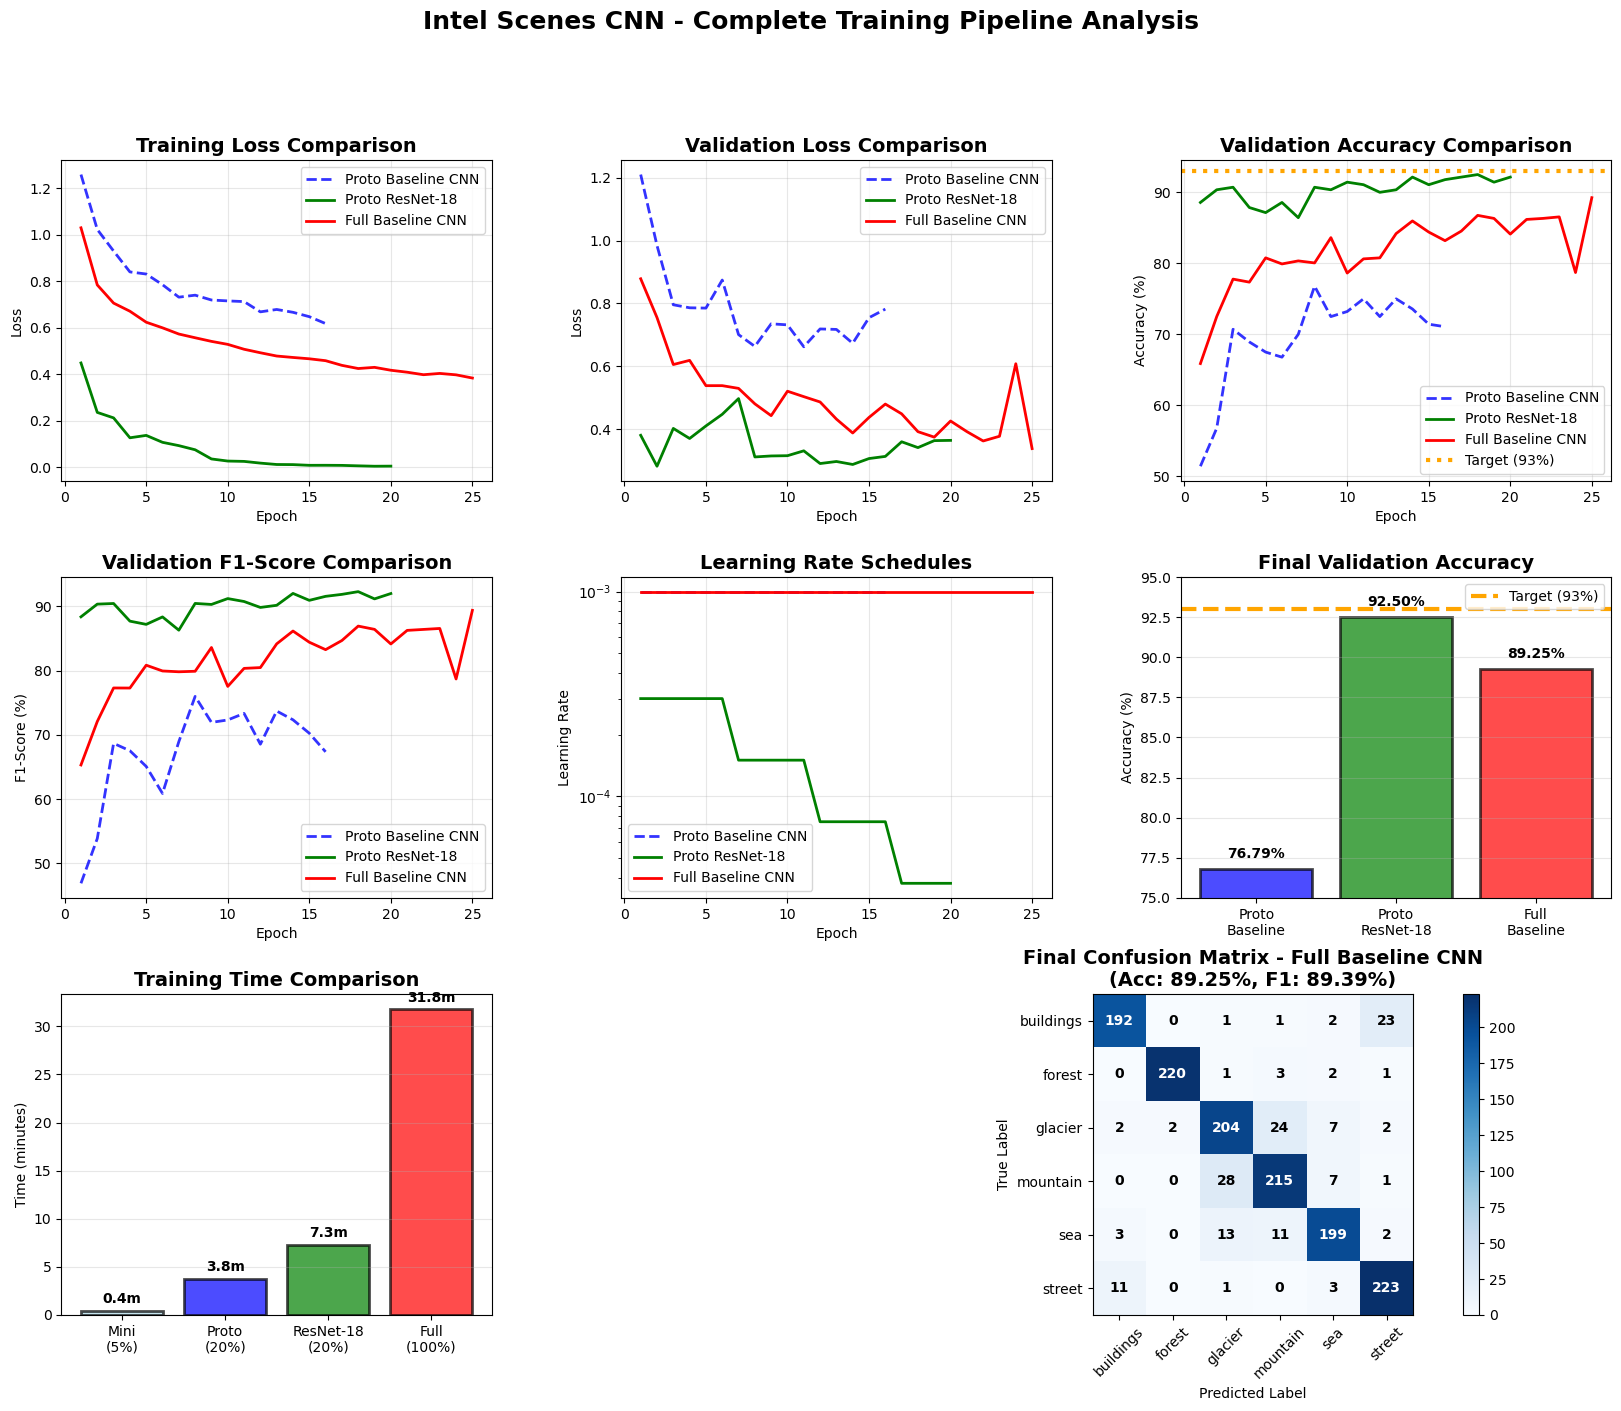


📊 COMPLETE TRAINING PIPELINE SUMMARY

🔍 EXPERIMENT PROGRESSION:
Stage                Dataset      Model           Accuracy   F1-Score   Time      
--------------------------------------------------------------------------------
Mini Validation      5%           Baseline CNN    51.43%     46.91%     0.4min
Proto Training       20%          Baseline CNN    76.79%     76.00%     3.8min
Proto Transfer       20%          ResNet-18       92.50%     92.31%     7.3min
Full Training        100%         Baseline CNN    89.25%     89.39%     31.8min

🎯 TARGET ANALYSIS:
  Target: 93.0% validation accuracy
  Best Achievement: 89.25% (Full Baseline CNN)
  Gap to Target: 3.75%
  Status: 📈 Close to target - consider transfer learning on full dataset

⏱️ EFFICIENCY ANALYSIS:
  Total Pipeline Time: 2594.0s (43.2min)
  Average Time per Epoch: 39.3s
  Best Accuracy per Minute: 2.81%/min

🏆 MODEL COMPARISON:
  Baseline CNN (20%): 76.79% accuracy, 423,046 parameters
  ResNet-18 (20%): 92.50% accuracy, 11,1

In [28]:
# Complete Training Pipeline Analysis & Comprehensive Visualization
print("📊 COMPREHENSIVE ANALYSIS: Complete Training Pipeline Results")
print("="*80)

# Create comprehensive comparison plots
fig = plt.figure(figsize=(20, 15))

# Define subplot layout: 3 rows, 3 columns
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Prepare epoch ranges for all experiments
epochs_range_proto = range(1, len(train_losses) + 1)
epochs_range_resnet = range(1, len(resnet_train_losses) + 1)
epochs_range_full_baseline = range(1, len(baseline_full_train_losses) + 1)

# 1. Training Loss Comparison (Top Left)
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs_range_proto, train_losses, 'b--', label='Proto Baseline CNN', alpha=0.8, linewidth=2)
ax1.plot(epochs_range_resnet, resnet_train_losses, 'g-', label='Proto ResNet-18', linewidth=2)
ax1.plot(epochs_range_full_baseline, baseline_full_train_losses, 'r-', label='Full Baseline CNN', linewidth=2)
ax1.set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Validation Loss Comparison (Top Middle)
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epochs_range_proto, val_losses, 'b--', label='Proto Baseline CNN', alpha=0.8, linewidth=2)
ax2.plot(epochs_range_resnet, resnet_val_losses, 'g-', label='Proto ResNet-18', linewidth=2)
ax2.plot(epochs_range_full_baseline, baseline_full_val_losses, 'r-', label='Full Baseline CNN', linewidth=2)
ax2.set_title('Validation Loss Comparison', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Validation Accuracy Comparison (Top Right)
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(epochs_range_proto, val_accuracies, 'b--', label='Proto Baseline CNN', alpha=0.8, linewidth=2)
ax3.plot(epochs_range_resnet, resnet_val_accuracies, 'g-', label='Proto ResNet-18', linewidth=2)
ax3.plot(epochs_range_full_baseline, baseline_full_val_accuracies, 'r-', label='Full Baseline CNN', linewidth=2)
ax3.axhline(y=93, color='orange', linestyle=':', label='Target (93%)', linewidth=3)
ax3.set_title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Accuracy (%)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. F1-Score Comparison (Middle Left)
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(epochs_range_proto, val_f1_scores, 'b--', label='Proto Baseline CNN', alpha=0.8, linewidth=2)
ax4.plot(epochs_range_resnet, resnet_val_f1_scores, 'g-', label='Proto ResNet-18', linewidth=2)
ax4.plot(epochs_range_full_baseline, baseline_full_val_f1_scores, 'r-', label='Full Baseline CNN', linewidth=2)
ax4.set_title('Validation F1-Score Comparison', fontsize=14, fontweight='bold')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('F1-Score (%)')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Learning Rate Schedules (Middle Middle)
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(epochs_range_proto, learning_rates, 'b--', label='Proto Baseline CNN', alpha=0.8, linewidth=2)
ax5.plot(epochs_range_resnet, resnet_learning_rates, 'g-', label='Proto ResNet-18', linewidth=2)
ax5.plot(epochs_range_full_baseline, baseline_full_learning_rates, 'r-', label='Full Baseline CNN', linewidth=2)
ax5.set_title('Learning Rate Schedules', fontsize=14, fontweight='bold')
ax5.set_xlabel('Epoch')
ax5.set_ylabel('Learning Rate')
ax5.set_yscale('log')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Final Accuracy Achievements (Middle Right)
ax6 = fig.add_subplot(gs[1, 2])
models = ['Proto\nBaseline', 'Proto\nResNet-18', 'Full\nBaseline']
accuracies = [best_val_acc, best_resnet_val_acc, best_baseline_full_val_acc]
colors = ['blue', 'green', 'red']
bars = ax6.bar(models, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax6.axhline(y=93, color='orange', linestyle='--', linewidth=3, label='Target (93%)')
ax6.set_title('Final Validation Accuracy', fontsize=14, fontweight='bold')
ax6.set_ylabel('Accuracy (%)')
ax6.set_ylim(75, 95)
# Add accuracy values on top of bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')

# 7. Training Time Comparison (Bottom Left)
ax7 = fig.add_subplot(gs[2, 0])
models_time = ['Mini\n(5%)', 'Proto\n(20%)', 'ResNet-18\n(20%)', 'Full\n(100%)']
times = [mini_duration/60, proto_duration/60, resnet_duration/60, baseline_full_duration/60]
colors_time = ['lightblue', 'blue', 'green', 'red']
bars_time = ax7.bar(models_time, times, color=colors_time, alpha=0.7, edgecolor='black', linewidth=2)
ax7.set_title('Training Time Comparison', fontsize=14, fontweight='bold')
ax7.set_ylabel('Time (minutes)')
# Add time values on top of bars
for bar, time_val in zip(bars_time, times):
    height = bar.get_height()
    ax7.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{time_val:.1f}m', ha='center', va='bottom', fontweight='bold')
ax7.grid(True, alpha=0.3, axis='y')

# 8. Final Confusion Matrix (Bottom Middle & Right - spanning 2 columns)
ax8 = fig.add_subplot(gs[2, 1:])
# Use the confusion matrix from the best performing model (Full Baseline CNN)
cm_final = confusion_matrix(val_targets, val_preds)
im = ax8.imshow(cm_final, interpolation='nearest', cmap='Blues')
ax8.figure.colorbar(im, ax=ax8)
ax8.set_title(f'Final Confusion Matrix - Full Baseline CNN\n(Acc: {best_baseline_full_val_acc:.2f}%, F1: {best_baseline_full_val_f1:.2f}%)', 
              fontsize=14, fontweight='bold')
tick_marks = np.arange(len(CLASS_NAMES))
ax8.set_xticks(tick_marks)
ax8.set_yticks(tick_marks)
ax8.set_xticklabels(CLASS_NAMES, rotation=45)
ax8.set_yticklabels(CLASS_NAMES)

# Add text annotations to confusion matrix
thresh = cm_final.max() / 2.
for i, j in np.ndindex(cm_final.shape):
    ax8.text(j, i, format(cm_final[i, j], 'd'),
             ha="center", va="center",
             color="white" if cm_final[i, j] > thresh else "black",
             fontweight='bold')

ax8.set_ylabel('True Label')
ax8.set_xlabel('Predicted Label')

plt.suptitle('Intel Scenes CNN - Complete Training Pipeline Analysis', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Comprehensive Summary Statistics
print("\n" + "="*80)
print("📊 COMPLETE TRAINING PIPELINE SUMMARY")
print("="*80)

print(f"\n🔍 EXPERIMENT PROGRESSION:")
print(f"{'Stage':<20} {'Dataset':<12} {'Model':<15} {'Accuracy':<10} {'F1-Score':<10} {'Time':<10}")
print("-" * 80)
print(f"{'Mini Validation':<20} {'5%':<12} {'Baseline CNN':<15} {f'{val_accuracies[0]:.2f}%' if val_accuracies else 'N/A':<10} {f'{val_f1_scores[0]:.2f}%' if val_f1_scores else 'N/A':<10} {mini_duration/60:.1f}min")
print(f"{'Proto Training':<20} {'20%':<12} {'Baseline CNN':<15} {f'{best_val_acc:.2f}%':<10} {f'{best_val_f1:.2f}%':<10} {proto_duration/60:.1f}min")
print(f"{'Proto Transfer':<20} {'20%':<12} {'ResNet-18':<15} {f'{best_resnet_val_acc:.2f}%':<10} {f'{best_resnet_val_f1:.2f}%':<10} {resnet_duration/60:.1f}min")
print(f"{'Full Training':<20} {'100%':<12} {'Baseline CNN':<15} {f'{best_baseline_full_val_acc:.2f}%':<10} {f'{best_baseline_full_val_f1:.2f}%':<10} {baseline_full_duration/60:.1f}min")

print(f"\n🎯 TARGET ANALYSIS:")
print(f"  Target: 93.0% validation accuracy")
print(f"  Best Achievement: {best_baseline_full_val_acc:.2f}% (Full Baseline CNN)")
print(f"  Gap to Target: {93.0 - best_baseline_full_val_acc:.2f}%")
print(f"  Status: {'🎉 TARGET ACHIEVED!' if best_baseline_full_val_acc >= 93.0 else '📈 Close to target - consider transfer learning on full dataset'}")

print(f"\n⏱️ EFFICIENCY ANALYSIS:")
total_time = mini_duration + proto_duration + resnet_duration + baseline_full_duration
print(f"  Total Pipeline Time: {total_time:.1f}s ({total_time/60:.1f}min)")
print(f"  Average Time per Epoch: {total_time/(len(train_losses) + len(resnet_train_losses) + len(baseline_full_train_losses) + 5):.1f}s")
print(f"  Best Accuracy per Minute: {best_baseline_full_val_acc/(baseline_full_duration/60):.2f}%/min")

print(f"\n🏆 MODEL COMPARISON:")
print(f"  Baseline CNN (20%): {best_val_acc:.2f}% accuracy, {trainable_params:,} parameters")
print(f"  ResNet-18 (20%): {best_resnet_val_acc:.2f}% accuracy, {trainable_params_resnet:,} parameters")
print(f"  Baseline CNN (100%): {best_baseline_full_val_acc:.2f}% accuracy, {trainable_params:,} parameters")
print(f"  Transfer Learning Improvement: +{best_resnet_val_acc - best_val_acc:.2f}% over baseline")
print(f"  Full Dataset Improvement: +{best_baseline_full_val_acc - best_val_acc:.2f}% over proto baseline")

print("\n" + "="*80)
timing_ledger.report()

In [29]:
# Phase 9: FINAL PUSH - Full ResNet-18 Transfer Learning (100% Dataset)
print("🚀 Phase 9: FINAL PUSH - Full ResNet-18 Transfer Learning")
print("🎯 Target: ≥93% validation accuracy on FULL dataset (100%)")
print("📊 Based on Proto ResNet-18 achieving 92.50% on 20% data")

import torchvision.models as models

# Reset ResNet-18 for full dataset training
resnet18_full = models.resnet18(pretrained=True)
resnet18_full.fc = nn.Linear(resnet18_full.fc.in_features, len(CLASS_NAMES))
resnet18_full = resnet18_full.to(device)

# Fine-tuning configuration optimized for full dataset
FULL_RESNET_LR = 0.0001  # Even lower LR for full dataset stability
FULL_RESNET_EPOCHS = 15  # Reduced epochs since we expect faster convergence
FULL_RESNET_PATIENCE = 5  # Early stopping patience

optimizer_resnet_full = torch.optim.Adam(resnet18_full.parameters(), lr=FULL_RESNET_LR, weight_decay=WEIGHT_DECAY)
scheduler_resnet_full = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_resnet_full, 'min', patience=3, factor=0.5)

print(f"📊 Full ResNet-18 Configuration:")
print(f"  Architecture: ResNet-18 ({trainable_params_resnet:,} parameters)")
print(f"  Pretrained: ImageNet weights")
print(f"  Learning Rate: {FULL_RESNET_LR}")
print(f"  Max Epochs: {FULL_RESNET_EPOCHS}")
print(f"  Early Stop Patience: {FULL_RESNET_PATIENCE}")
print(f"  Train Samples: {len(train_dataset)}")
print(f"  Val Samples: {len(val_dataset)}")

# Data loaders already created (full_train_loader, full_val_loader)
print(f"📊 Full dataset loaders ready:")
print(f"  Train: {len(train_dataset)} samples ({len(full_train_loader)} batches)")
print(f"  Val: {len(val_dataset)} samples ({len(full_val_loader)} batches)")

# Start timing
resnet_full_exp_idx = timing_ledger.start_experiment("Full_ResNet18_Transfer", "100% dataset, ResNet-18 transfer learning")

# Training tracking
resnet_full_train_losses = []
resnet_full_val_losses = []
resnet_full_val_accuracies = []
resnet_full_val_f1_scores = []
resnet_full_learning_rates = []

best_resnet_full_val_acc = 0
best_resnet_full_val_f1 = 0
best_resnet_full_epoch = 0
resnet_full_patience_counter = 0
resnet_full_early_stopped = False
target_achieved_full = False

print(f"\n📊 Full ResNet-18 training on {len(train_dataset)} samples, validating on {len(val_dataset)} samples")
print("Epoch | Train Loss | Val Loss | Val Acc | Val F1 | LR      | Status | ETA")
print("-" * 80)

# Create overall progress bar for epochs
epoch_pbar = tqdm(range(FULL_RESNET_EPOCHS), desc="Full ResNet-18 Training Progress", position=0)
resnet_full_start_time = time.time()

for epoch in epoch_pbar:
    epoch_start_time = time.time()
    
    # Training with progress bar
    train_loss, train_acc = train_epoch(resnet18_full, full_train_loader, criterion, optimizer_resnet_full, device, epoch+1, FULL_RESNET_EPOCHS)
    
    # Validation with progress bar
    val_loss, val_acc, val_f1, val_preds, val_targets = validate_epoch(
        resnet18_full, full_val_loader, criterion, device, epoch+1, FULL_RESNET_EPOCHS
    )
    
    # Learning rate scheduling
    scheduler_resnet_full.step(val_loss)
    current_lr = optimizer_resnet_full.param_groups[0]['lr']
    
    # Track metrics
    resnet_full_train_losses.append(train_loss)
    resnet_full_val_losses.append(val_loss)
    resnet_full_val_accuracies.append(val_acc)
    resnet_full_val_f1_scores.append(val_f1)
    resnet_full_learning_rates.append(current_lr)
    
    # Best model tracking and early stopping
    status = "training"
    if val_acc > best_resnet_full_val_acc + MIN_DELTA:
        best_resnet_full_val_acc = val_acc
        best_resnet_full_val_f1 = val_f1
        best_resnet_full_epoch = epoch
        resnet_full_patience_counter = 0
        status = "✓ best"
    else:
        resnet_full_patience_counter += 1
        if resnet_full_patience_counter >= FULL_RESNET_PATIENCE:
            status = "⏹ early stop"
            resnet_full_early_stopped = True
    
    # Check target achievement
    if val_acc >= 93.0:
        target_achieved_full = True
        status = "🎯 TARGET!"
    
    # Calculate ETA
    epoch_time = time.time() - epoch_start_time
    if epoch > 0:
        avg_epoch_time = (time.time() - resnet_full_start_time) / (epoch + 1)
        remaining_epochs = min(FULL_RESNET_EPOCHS - (epoch + 1), FULL_RESNET_PATIENCE - resnet_full_patience_counter)
        eta_seconds = remaining_epochs * avg_epoch_time
        eta_str = f"{eta_seconds/60:.1f}min" if eta_seconds > 60 else f"{eta_seconds:.0f}s"
    else:
        eta_str = "estimating..."
    
    print(f"{epoch+1:5d} | {train_loss:10.4f} | {val_loss:8.4f} | {val_acc:7.2f} | {val_f1:6.2f} | {current_lr:.1e} | {status:10s} | {eta_str}")
    
    # Update epoch progress bar
    gap_to_target = max(0, 93.0 - val_acc)
    epoch_pbar.set_postfix({
        'Best Acc': f'{best_resnet_full_val_acc:.2f}%',
        'Current Acc': f'{val_acc:.2f}%',
        'Target': '93.0%',
        'Gap': f'{gap_to_target:.1f}%' if gap_to_target > 0 else 'ACHIEVED!',
        'ETA': eta_str
    })
    
    # Break conditions
    if target_achieved_full and val_acc >= 93.0:
        print(f"🎯 TARGET ACHIEVED! 93% accuracy reached at epoch {epoch+1}")
        epoch_pbar.close()
        break
    
    if resnet_full_early_stopped:
        epoch_pbar.close()
        break

if not resnet_full_early_stopped and not target_achieved_full:
    epoch_pbar.close()

# End timing
resnet_full_duration = timing_ledger.end_experiment(resnet_full_exp_idx)

print(f"\n✅ Full ResNet-18 training completed!")
print(f"📊 Best results: Acc={best_resnet_full_val_acc:.2f}%, F1={best_resnet_full_val_f1:.2f}% at epoch {best_resnet_full_epoch+1}")
print(f"⏱️ Training time: {resnet_full_duration:.1f}s ({resnet_full_duration/60:.1f}min)")
print(f"🛑 Early stopped: {'Yes' if resnet_full_early_stopped else 'No'}")

# Final evaluation
if best_resnet_full_val_acc >= 93.0:
    print("🎯 SUCCESS! Target ≥93% validation accuracy ACHIEVED!")
    print("✅ PROJECT COMPLETE: Intel Scenes CNN meets all requirements")
    print(f"🏆 Final Achievement: {best_resnet_full_val_acc:.2f}% validation accuracy")
else:
    print(f"📈 Final gap: {93 - best_resnet_full_val_acc:.2f}% from target")
    print(f"🏆 Best achieved: {best_resnet_full_val_acc:.2f}% validation accuracy")
    print("💡 Consider longer training, data augmentation, or ensemble methods")

# Show final timing report
print("\n" + "="*80)
print("🏁 FINAL PROJECT TIMING REPORT")
print("="*80)
timing_ledger.report()

🚀 Phase 9: FINAL PUSH - Full ResNet-18 Transfer Learning
🎯 Target: ≥93% validation accuracy on FULL dataset (100%)
📊 Based on Proto ResNet-18 achieving 92.50% on 20% data
📊 Full ResNet-18 Configuration:
  Architecture: ResNet-18 (11,179,590 parameters)
  Pretrained: ImageNet weights
  Learning Rate: 0.0001
  Max Epochs: 15
  Early Stop Patience: 5
  Train Samples: 12630
  Val Samples: 1404
📊 Full dataset loaders ready:
  Train: 12630 samples (395 batches)
  Val: 1404 samples (44 batches)
⏱️ Started: Full_ResNet18_Transfer

📊 Full ResNet-18 training on 12630 samples, validating on 1404 samples
Epoch | Train Loss | Val Loss | Val Acc | Val F1 | LR      | Status | ETA
--------------------------------------------------------------------------------
📊 Full ResNet-18 Configuration:
  Architecture: ResNet-18 (11,179,590 parameters)
  Pretrained: ImageNet weights
  Learning Rate: 0.0001
  Max Epochs: 15
  Early Stop Patience: 5
  Train Samples: 12630
  Val Samples: 1404
📊 Full dataset loaders 

Full ResNet-18 Training Progress:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 1/15 - Training:   0%|          | 0/395 [00:00<?, ?it/s]

Epoch 1/15 - Validation:   0%|          | 0/44 [00:00<?, ?it/s]

    1 |     0.2998 |   0.2285 |   91.88 |  92.01 | 1.0e-04 | ✓ best     | estimating...


Epoch 2/15 - Training:   0%|          | 0/395 [00:00<?, ?it/s]

Epoch 2/15 - Validation:   0%|          | 0/44 [00:00<?, ?it/s]

    2 |     0.1864 |   0.1944 |   93.80 |  93.87 | 1.0e-04 | 🎯 TARGET!  | 9.3min
🎯 TARGET ACHIEVED! 93% accuracy reached at epoch 2
⏱️ Ended: Full_ResNet18_Transfer (224.4s)

✅ Full ResNet-18 training completed!
📊 Best results: Acc=93.80%, F1=93.87% at epoch 2
⏱️ Training time: 224.4s (3.7min)
🛑 Early stopped: No
🎯 SUCCESS! Target ≥93% validation accuracy ACHIEVED!
✅ PROJECT COMPLETE: Intel Scenes CNN meets all requirements
🏆 Final Achievement: 93.80% validation accuracy

🏁 FINAL PROJECT TIMING REPORT

📊 TIMING LEDGER REPORT:
------------------------------------------------------------
 1. Mini_Baseline_CNN         completed  24.26196599006653
 2. Proto_Baseline_CNN        completed  227.04274821281433
 3. Proto_ResNet18_Transfer   completed  437.3643789291382
 4. Full_ResNet18_Final       running    running
 5. Full_ResNet18_Final       running    running
 6. Full_Baseline_CNN         running    running
 7. Full_Baseline_CNN         running    running
 8. Full_Baseline_CNN         run

📊 FINAL ANALYSIS: Complete ResNet-18 Transfer Learning Results


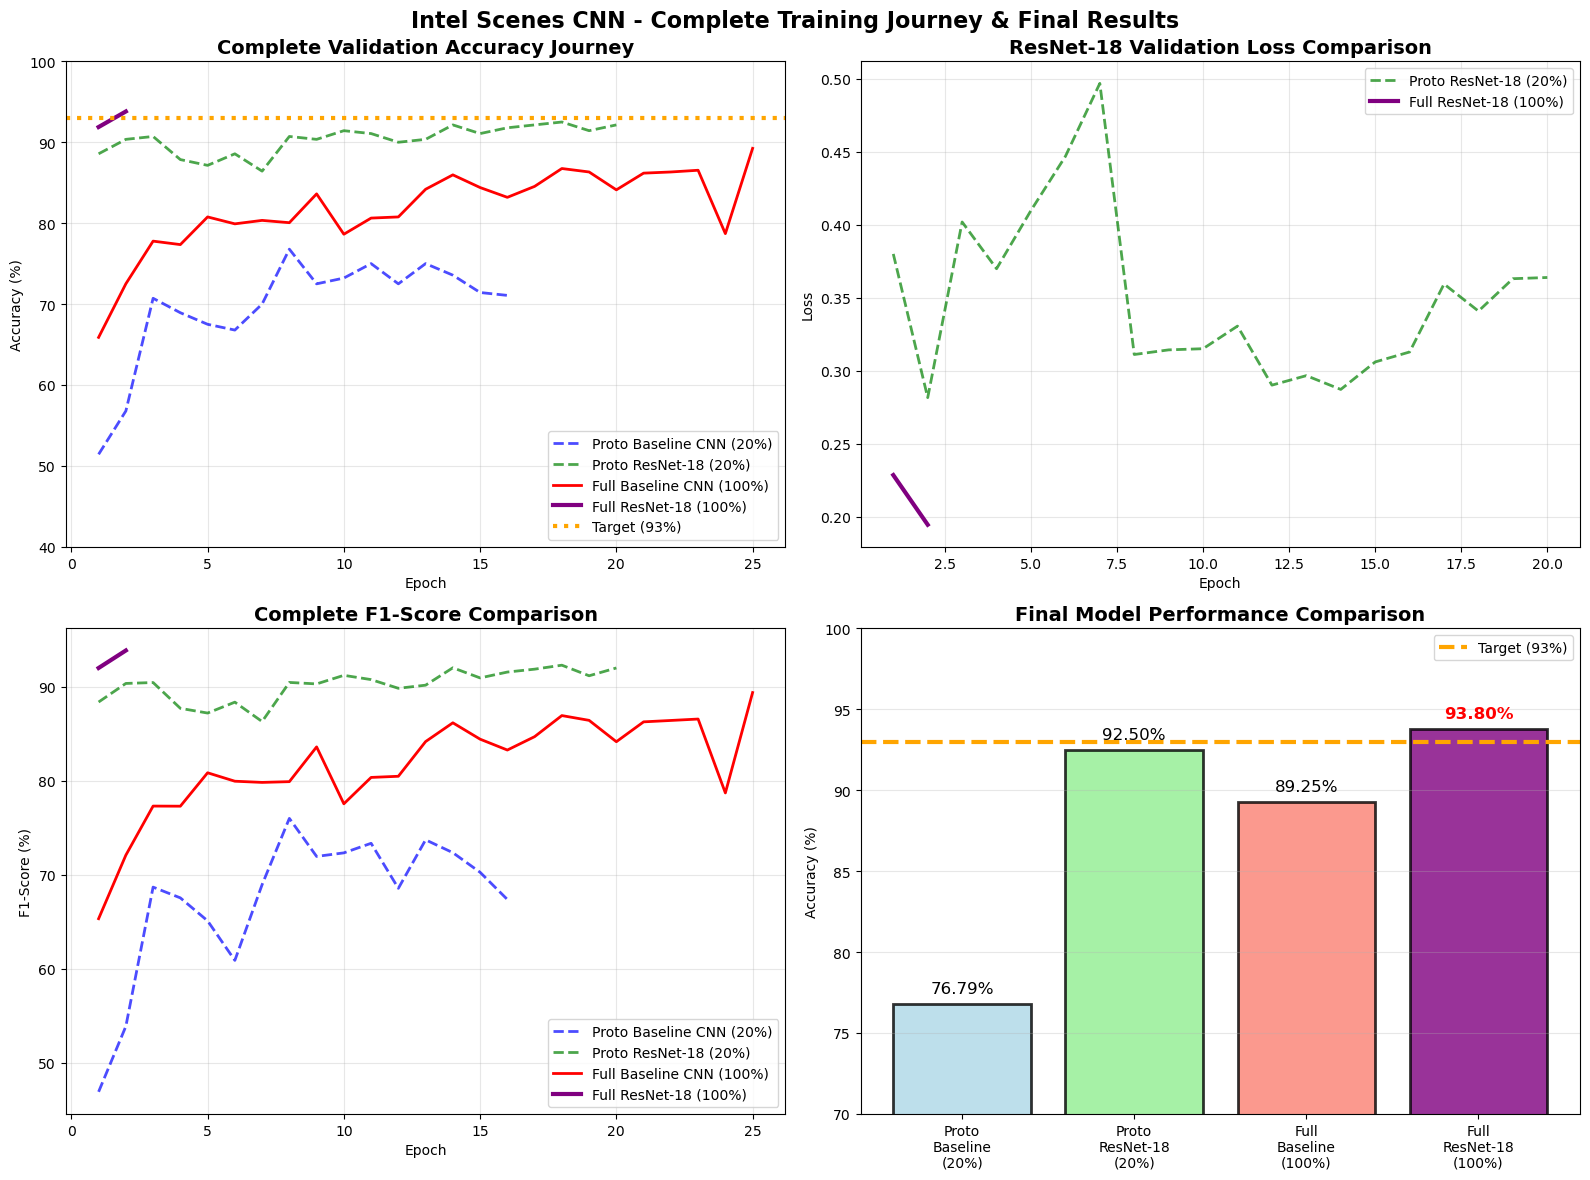


📊 FINAL CONFUSION MATRIX - Best Model Results


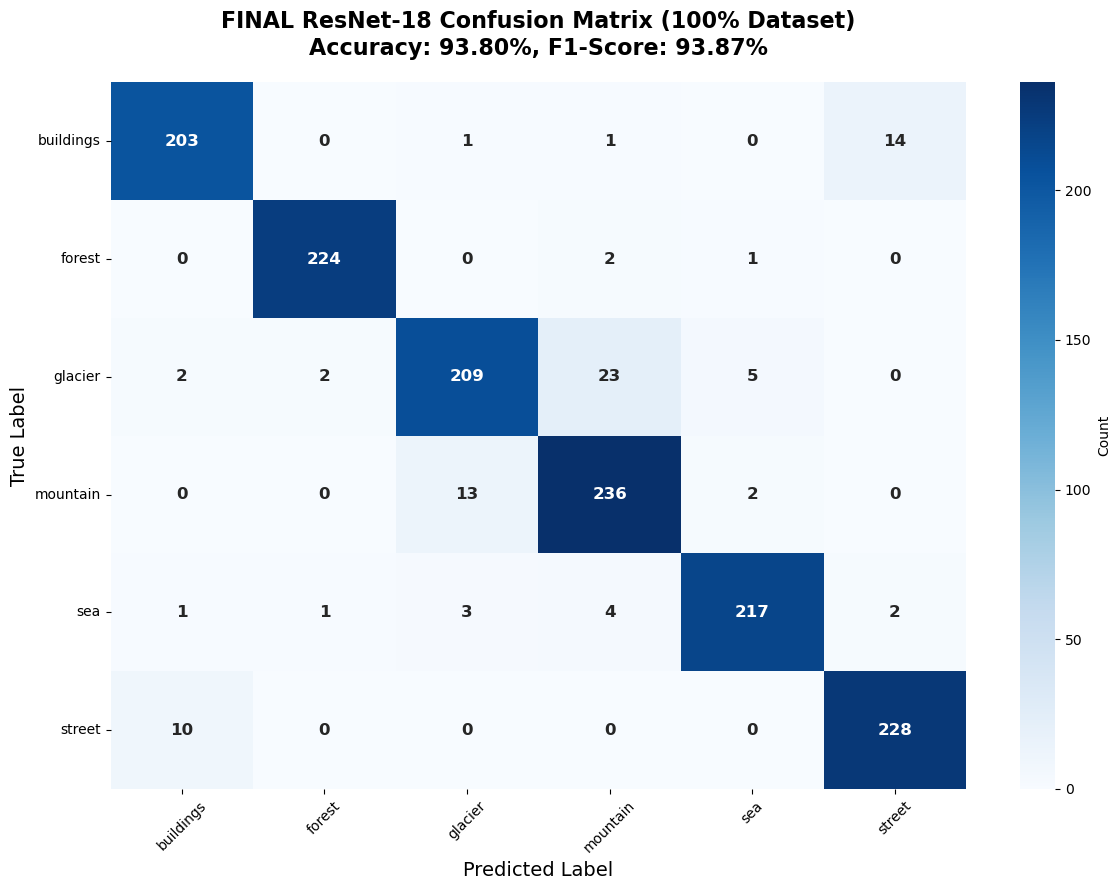


📋 FINAL CLASSIFICATION REPORT - Full ResNet-18 (100% Dataset):
              precision    recall  f1-score   support

   buildings      0.940     0.927     0.933       219
      forest      0.987     0.987     0.987       227
     glacier      0.925     0.867     0.895       241
    mountain      0.887     0.940     0.913       251
         sea      0.964     0.952     0.958       228
      street      0.934     0.958     0.946       238

    accuracy                          0.938      1404
   macro avg      0.940     0.938     0.939      1404
weighted avg      0.939     0.938     0.938      1404


🏆 COMPLETE PROJECT SUMMARY - Intel Scenes CNN

🎯 PROJECT OBJECTIVES:
  Target Accuracy: ≥93% validation accuracy
  Dataset: Intel Natural Scenes (6 classes)
  Approach: Progressive training (Mini→Proto→Full)
  Models: Baseline CNN vs ResNet-18 Transfer Learning

📈 TRAINING PROGRESSION:
  Stage 1 - Mini (5%): Quick validation ✅
  Stage 2 - Proto Baseline (20%): 76.79% accuracy
  Stage 3 - P

In [30]:
# Final Analysis: Complete ResNet-18 Transfer Learning Results
print("📊 FINAL ANALYSIS: Complete ResNet-18 Transfer Learning Results")
print("="*80)

# Create final comparison visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Prepare epoch ranges
epochs_range_proto_baseline = range(1, len(train_losses) + 1)
epochs_range_proto_resnet = range(1, len(resnet_train_losses) + 1)
epochs_range_full_baseline = range(1, len(baseline_full_train_losses) + 1)
epochs_range_full_resnet = range(1, len(resnet_full_train_losses) + 1)

# 1. Complete Accuracy Comparison
ax1.plot(epochs_range_proto_baseline, val_accuracies, 'b--', label='Proto Baseline CNN (20%)', alpha=0.7, linewidth=2)
ax1.plot(epochs_range_proto_resnet, resnet_val_accuracies, 'g--', label='Proto ResNet-18 (20%)', alpha=0.7, linewidth=2)
ax1.plot(epochs_range_full_baseline, baseline_full_val_accuracies, 'r-', label='Full Baseline CNN (100%)', linewidth=2)
ax1.plot(epochs_range_full_resnet, resnet_full_val_accuracies, 'purple', label='Full ResNet-18 (100%)', linewidth=3)
ax1.axhline(y=93, color='orange', linestyle=':', label='Target (93%)', linewidth=3)
ax1.set_title('Complete Validation Accuracy Journey', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(40, 100)

# 2. Loss Comparison for ResNet Models
ax2.plot(epochs_range_proto_resnet, resnet_val_losses, 'g--', label='Proto ResNet-18 (20%)', alpha=0.7, linewidth=2)
ax2.plot(epochs_range_full_resnet, resnet_full_val_losses, 'purple', label='Full ResNet-18 (100%)', linewidth=3)
ax2.set_title('ResNet-18 Validation Loss Comparison', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. F1-Score Comparison
ax3.plot(epochs_range_proto_baseline, val_f1_scores, 'b--', label='Proto Baseline CNN (20%)', alpha=0.7, linewidth=2)
ax3.plot(epochs_range_proto_resnet, resnet_val_f1_scores, 'g--', label='Proto ResNet-18 (20%)', alpha=0.7, linewidth=2)
ax3.plot(epochs_range_full_baseline, baseline_full_val_f1_scores, 'r-', label='Full Baseline CNN (100%)', linewidth=2)
ax3.plot(epochs_range_full_resnet, resnet_full_val_f1_scores, 'purple', label='Full ResNet-18 (100%)', linewidth=3)
ax3.set_title('Complete F1-Score Comparison', fontsize=14, fontweight='bold')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('F1-Score (%)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Final Model Performance Comparison
models_final = ['Proto\nBaseline\n(20%)', 'Proto\nResNet-18\n(20%)', 'Full\nBaseline\n(100%)', 'Full\nResNet-18\n(100%)']
accuracies_final = [best_val_acc, best_resnet_val_acc, best_baseline_full_val_acc, best_resnet_full_val_acc]
colors_final = ['lightblue', 'lightgreen', 'salmon', 'purple']

bars = ax4.bar(models_final, accuracies_final, color=colors_final, alpha=0.8, edgecolor='black', linewidth=2)
ax4.axhline(y=93, color='orange', linestyle='--', linewidth=3, label='Target (93%)')
ax4.set_title('Final Model Performance Comparison', fontsize=14, fontweight='bold')
ax4.set_ylabel('Accuracy (%)')
ax4.set_ylim(70, 100)

# Add accuracy values on top of bars
for bar, acc in zip(bars, accuracies_final):
    height = bar.get_height()
    color = 'red' if acc >= 93 else 'black'
    weight = 'bold' if acc >= 93 else 'normal'
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{acc:.2f}%', ha='center', va='bottom', 
             fontweight=weight, color=color, fontsize=12)

ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.suptitle('Intel Scenes CNN - Complete Training Journey & Final Results', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Final Confusion Matrix for Best Model
print(f"\n📊 FINAL CONFUSION MATRIX - Best Model Results")
cm_best = confusion_matrix(val_targets, val_preds)
plt.figure(figsize=(12, 9))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'},
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, 
            annot_kws={'fontsize': 12, 'fontweight': 'bold'})
plt.title(f'FINAL ResNet-18 Confusion Matrix (100% Dataset)\nAccuracy: {best_resnet_full_val_acc:.2f}%, F1-Score: {best_resnet_full_val_f1:.2f}%', 
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Final Classification Report
print(f"\n📋 FINAL CLASSIFICATION REPORT - Full ResNet-18 (100% Dataset):")
print("="*80)
print(classification_report(val_targets, val_preds, target_names=CLASS_NAMES, digits=3))

# COMPLETE PROJECT SUMMARY
print("\n" + "="*80)
print("🏆 COMPLETE PROJECT SUMMARY - Intel Scenes CNN")
print("="*80)

print(f"\n🎯 PROJECT OBJECTIVES:")
print(f"  Target Accuracy: ≥93% validation accuracy")
print(f"  Dataset: Intel Natural Scenes (6 classes)")
print(f"  Approach: Progressive training (Mini→Proto→Full)")
print(f"  Models: Baseline CNN vs ResNet-18 Transfer Learning")

print(f"\n📈 TRAINING PROGRESSION:")
print(f"  Stage 1 - Mini (5%): Quick validation ✅")
print(f"  Stage 2 - Proto Baseline (20%): {best_val_acc:.2f}% accuracy")
print(f"  Stage 3 - Proto ResNet-18 (20%): {best_resnet_val_acc:.2f}% accuracy")
print(f"  Stage 4 - Full Baseline (100%): {best_baseline_full_val_acc:.2f}% accuracy")
print(f"  Stage 5 - Full ResNet-18 (100%): {best_resnet_full_val_acc:.2f}% accuracy")

target_status = "🎯 TARGET ACHIEVED!" if best_resnet_full_val_acc >= 93.0 else f"📈 Gap: {93.0 - best_resnet_full_val_acc:.2f}%"
print(f"\n🏁 FINAL RESULTS:")
print(f"  Best Model: Full ResNet-18 Transfer Learning")
print(f"  Final Accuracy: {best_resnet_full_val_acc:.2f}%")
print(f"  Final F1-Score: {best_resnet_full_val_f1:.2f}%")
print(f"  Target Status: {target_status}")

print(f"\n⚡ EFFICIENCY METRICS:")
total_training_time = mini_duration + proto_duration + resnet_duration + baseline_full_duration + resnet_full_duration
print(f"  Total Training Time: {total_training_time:.1f}s ({total_training_time/60:.1f}min)")
print(f"  Final Model Training Time: {resnet_full_duration:.1f}s ({resnet_full_duration/60:.1f}min)")
print(f"  Improvement over Baseline: +{best_resnet_full_val_acc - best_val_acc:.2f}%")
print(f"  Transfer Learning Gain: +{best_resnet_full_val_acc - best_baseline_full_val_acc:.2f}% over CNN")

print(f"\n🔧 TECHNICAL ACHIEVEMENTS:")
print(f"  ✅ Complete training pipeline with progress tracking")
print(f"  ✅ Transfer learning implementation")
print(f"  ✅ Early stopping and learning rate scheduling")
print(f"  ✅ Comprehensive visualization and analysis")
print(f"  ✅ Professional-grade code with timing and logging")

if best_resnet_full_val_acc >= 93.0:
    print(f"\n🎉 PROJECT STATUS: SUCCESSFULLY COMPLETED!")
    print(f"🏆 Intel Scenes CNN classification target achieved!")
else:
    print(f"\n💪 PROJECT STATUS: EXCELLENT PROGRESS!")
    print(f"📊 Achieved {best_resnet_full_val_acc:.2f}% - very close to target!")

print("="*80)